In [135]:
# Importing all the main libraries needed for this project
# These libraries help work with datasets, do calculations, and make visuals to better understand 
# patterns in traffic and air quality data

# Import pandas for handling and analyizing structured dta (like tables/dataframes)
import pandas as pd

# Import seaborn for makin nicer looking statistical visualizations
import seaborn as sns

# Import matplotlib's pyplot module for creating basic plots and charts
import matplotlib.pyplot as plt

# Import numpy for numerical operations, especially arrays and math function in general
import numpy as np

In [136]:
# Loading the cleaned datasets into a pandas dataframe
# Each dataset represents a different part of our project (fine particles, NO2, traffic)
# and loading them allows us to start analyzing and combining the data

# Load the cleaned fine particle dataset into a dataframe
df_particles = pd.read_csv('processed_data/cleaned_fine_particles_data.csv')

# Load the cleaned nitrogen dioxide (NO2) dataset into a dataframe
df_no2 = pd.read_csv('processed_data/cleaned_nitrogen_dioxide_data.csv')

# Load the cleaned traffic volume dataset into a dataframe
df_traffic = pd.read_csv('processed_data/cleaned_traffic_data.csv')

In [137]:
# Check the data types of specific columns in the datasets
# Helps understand how the data is currently stored (like strings, datetime, etc)
# This is important before doing any time-based analysis or transformations

# Print out the data type of the first value in the 'DateTime' column from the traffic dataset
print("RAW TRAFFIC TYPE:", type(df_traffic['DateTime'].iloc[0]))

# Print out the data type of the first value in the 'TimePeriod' column from the fine particles dataset
print("RAW PARTICLES TYPE:", type(df_particles['TimePeriod'].iloc[0]))

RAW TRAFFIC TYPE: <class 'str'>
RAW PARTICLES TYPE: <class 'str'>


In [138]:
# Convert the one-hot encoded borough columns into a single text column
# This makes the data easier to read and work with later on, especially for grouping and analysis
# Also we handled the Bronx separately since it is not included in the one-hot encoded columns,
# and then save the updated datasets back to their respective CSV files

### Add a new column that will store the borough name as text instead of one-hot encoding

# List of one-hot encoded borough columns for fine particles and NO2 datasets
cols = ['Borough_Manhattan', 'Borough_Brooklyn', 'Borough_Queens', 'Borough_Staten Island']

# Convert the one-hot encoded columns into a single 'Borough' text column which is for the fine particles dataset
df_particles['Borough'] = df_particles[cols].idxmax(axis = 1).str.replace('Borough_', '')

# If none of the one-hot columns are 1, assign 'Bronx' as the borough since it is missing from the list
df_particles.loc[df_particles[cols].sum(axis = 1) == 0, 'Borough'] = 'Bronx'

# Save the updated fine particles dataset back to the CSV file
df_particles.to_csv('processed_data/cleaned_fine_particles_data.csv', index = False)

# Convert one-hot encoded columns into a single 'Borough' text column which is for the NO2 dataset
df_no2['Borough'] = df_no2[cols].idxmax(axis = 1).str.replace('Borough_', '')

# Assign 'Bronx' where no borough was selected in the one-hot columns which is for the NO2 dataset
df_no2.loc[df_no2[cols].sum(axis = 1) == 0, 'Borough'] = 'Bronx'

# Save the updated NO2 dataset back to the CSV file
df_no2.to_csv('processed_data/cleaned_nitrogen_dioxide_data.csv', index = False)

# List of one-hot encoded borough columns for the traffic dataset with slighly different naming
traffic_cols = ['Boro_Manhattan', 'Boro_Brooklyn', 'Boro_Queens', 'Boro_Staten Island']

# Convert the one-hot encoded columns into a single 'Boro' text column which is for the traffic dataset
df_traffic['Boro'] = df_traffic[traffic_cols].idxmax(axis = 1).str.replace('Boro_', '')

# Assign 'Bronx' where no borough was selected in the one-hot columns which is for the traffic dataset
df_traffic.loc[df_traffic[traffic_cols].sum(axis = 1) == 0, 'Boro'] = 'Bronx'

# Save the updated traffic dataset back to the CSV file
df_traffic.to_csv('processed_data/cleaned_traffic_data.csv', index = False)

In [139]:
# Prepare the cleaned datasets for database storage and analysis
# Includes renaming the columsn for consistency, converting date formats, creating seasonal features,
# reshaping the data into a more usable format, and storing everything into a SQL databse
# At the end, we made a master table by joining all the datasets together for easier analysis

### SQL setup

# Import sqlite3 to work with a local SQL database
import sqlite3

# Create a connection to the database file which will create the file if it does not already exist
conn = sqlite3.connect('main.db')

# Update the column names in the fine particles dataset to fix formatting issues
df_particles = df_particles.rename(columns = {
    # Fix spacing in the column name
    'Borough_Staten Island': 'Borough_Staten_Island',
    # Standardize the date column name
    'TimePeriod': 'Date'
})

# Updated the column names in the NO2 dataset to fix formatting issues
df_no2 = df_no2.rename(columns = {
    # Fix spacing in the column name
    'Borough_Staten Island': 'Borough_Staten_Island',
    # Standardize the date column name
    'TimePeriod': 'Date'
})

# Updated the column names in the traffic dataset so everything lines up across dataset
df_traffic = df_traffic.rename(columns = {
    # Rename the prefix for Boro to Borough
    'Boro_Manhattan': 'Borough_Manhattan',
    # Rename the prefix for Boro to Borough
    'Boro_Brooklyn': 'Borough_Brooklyn',
    # Rename the prefix for Boro to Borough
    'Boro_Queens': 'Borough_Queens',
    # Fix the spacing and rename the prefix for Boro to Borough
    'Boro_Staten Island': 'Borough_Staten_Island',
    # Standardize the date column name
    'DateTime': 'Date',
    # Rename the borough column to match the others
    'Boro': 'Borough'
})

### Clean and covert datetime columns

# Convert the traffic date column into a proper datetime object
df_traffic['Date'] = pd.to_datetime(df_traffic['Date'])

# Convert the fine particles date column into a proper datetime format
df_particles['Date'] = pd.to_datetime(df_particles['Date'])

# Convert the NO2 date column into a proper datetime format
df_no2['Date'] = pd.to_datetime(df_no2['Date'])

### Create Seasonal feature from month

# Get the month from the traffic dataset
df_traffic['Month'] = df_traffic['Date'].dt.month

# Rules for assigning season based on the month
rules = [
    # Months considered Winter
    df_traffic['Month'].isin([12, 1, 2]),
    # Months considered Summer
    df_traffic['Month'].isin([6, 7, 8])
]

# The labels that correspond to those rules
choices = ['Winter', 'Summer']

# Make a new 'Season' column using the rules above
df_traffic['Season'] = np.select(rules, choices, default='Other')

### Extract only the year

# Replace the full datetime with just the year for the traffic dataset
df_traffic['Date'] = df_traffic['Date'].dt.year

# Replace the full datetime with just the year for the fine particles dataset
df_particles['Date'] = df_particles['Date'].dt.year

# Replace the full datetime with just the year for the NO2 dataset
df_no2['Date'] = df_no2['Date'].dt.year

### Restructure the particles dataset

# These are the columns that we want to keep fixed when reshaping
p_cols = ['Date', 'Borough', 'Borough_Brooklyn', 'Borough_Manhattan', 
        'Borough_Queens', 'Borough_Staten_Island', 
        'Annual mean mcg/m3', 'Annual mean mcg/m3_log'
]

# Reshape the seasonal particle values into a long format
df_p_val = df_particles.melt(
    # Columns that stay the same
    id_vars = p_cols,
    # Columns to be reshaped
    value_vars = ['Summer mean mcg/m3', 'Winter mean mcg/m3'],
    # New column that stores the season
    var_name = 'Season',
    # New column for the values
    value_name = 'Fine_Particles_Value')

# Clean up the season labels by removing the extra text
df_p_val['Season'] = df_p_val['Season'].str.replace(' mean mcg/m3', '').str.strip()

# Reshape the particle log vlaues into a long format
df_p_log = df_particles.melt(
    # Keep onl the key identifiers
    id_vars = ['Date', 'Borough'],
    # Reshape these columns
    value_vars = ['Summer mean mcg/m3_log', 'Winter mean mcg/m3_log'],
    # New column that stores the season
    var_name = 'Season',
    # New column for the values
    value_name = 'Fine_Particles_Log')

# Clean up the season labels for the log dataset
df_p_log['Season'] = df_p_log['Season'].str.replace(' mean mcg/m3_log', '').str.strip()

# Merge the value and log datasets together into one final particles dataset
df_particles_final = df_p_val.merge(df_p_log, on = ['Date', 'Borough', 'Season'])

### Restructure the NO2 dataset

# The columns we want to keep fixed when reshaping the NO2 dataset
n_cols = ['Date', 'Borough', 'Borough_Brooklyn', 'Borough_Manhattan',
        'Borough_Queens', 'Borough_Staten_Island',
        'Annual mean ppb', 'Annual mean ppb_log'
]

# Reshape the NO2 seasonal values into a long format
df_n_val = df_no2.melt(
    id_vars = n_cols,
    value_vars = ['Summer mean ppb', 'Winter mean ppb'],
    var_name = 'Season',
    value_name = 'NO2_Value')

# Clean up the season labels
df_n_val['Season'] = df_n_val['Season'].str.replace(' mean ppb', '').str.strip()

# Reshape the NO2 log values into a long format
df_n_log = df_no2.melt(
    id_vars = ['Date', 'Borough'],
    value_vars = ['Summer mean ppb_log', 'Winter mean ppb_log'],
    var_name = 'Season',
    value_name = 'NO2_Log'
)

# Clean up the season labels for the log values
df_n_log['Season'] = df_n_log['Season'].str.replace(' mean ppb_log', '').str.strip()

# Merge the value and log datasets together into one final NO2 dataset
df_no2_final = df_n_val.merge(df_n_log, on = ['Date', 'Borough', 'Season'])

### Create the SQL tables

# Save the traffic dataset into a SQL table
df_traffic.to_sql('traffic_volume', conn, if_exists = 'replace', index = False)

# Save the processed fine particles dataset into a SQL table
df_particles_final.to_sql('fine_particles', conn, if_exists = 'replace', index = False)

# Save the processed NO2 dataset into a SQL table
df_no2_final.to_sql('nitrogen_dioxide', conn, if_exists = 'replace', index = False)

### Quick test to make sure that everything looks good

# Print all the column names in the traffic dataset
print("Traffic Columns:", df_traffic.columns.tolist())

# Print all the column names in the fine particles dataset
print("Particles Columns:", df_particles.columns.tolist())

# Print all the column names in the NO2 dataset
print("NO2 Columns:", df_no2.columns.tolist())

### Make a master table by joining all of the datasets

# SQL query that joins the traffic, particles, and NO2 into one table
master_query = """
CREATE TABLE master_data AS
SELECT 
    t.Date AS Year, 
    t.Month, 
    t.Borough, 
    t.Season, 
    t.Vol AS Traffic_Volume, 
    t.Vol_log AS Traffic_Volume_Log,
    p.Fine_Particles_Value, 
    p.Fine_Particles_Log,
    p."Annual mean mcg/m3" AS Annual_Particles_Mean,
    p."Annual mean mcg/m3_log" AS Annual_Particles_Log,
    n.NO2_Value,
    n.NO2_Log,
    n."Annual mean ppb" AS Annual_NO2_Mean,
    n."Annual mean ppb_log" AS Annual_NO2_Log,
    t.Borough_Manhattan,
    t.Borough_Brooklyn,
    t.Borough_Queens,
    t.Borough_Staten_Island
FROM traffic_volume t
JOIN fine_particles p 
    ON t.Date = p.Date AND t.Borough = p.Borough AND t.Season = p.Season
JOIN nitrogen_dioxide n
    ON t.Date = n.Date AND t.Borough = n.Borough AND t.Season = n.Season;
"""

# Drop the master table if it alraedy exists to avoid any errors
conn.execute("DROP TABLE IF EXISTS master_data") 

# Execute the SQL query to make the new master table
conn.execute(master_query)

Traffic Columns: ['RequestID', 'Vol', 'SegmentID', 'WktGeom', 'Direction', 'Date', 'Vol_log', 'Borough_Brooklyn', 'Borough_Manhattan', 'Borough_Queens', 'Borough_Staten_Island', 'Borough', 'Month', 'Season']
Particles Columns: ['Date', 'BoroID', 'Annual mean mcg/m3', 'Summer mean mcg/m3', 'Winter mean mcg/m3', 'Annual mean mcg/m3_log', 'Summer mean mcg/m3_log', 'Winter mean mcg/m3_log', 'Borough_Brooklyn', 'Borough_Manhattan', 'Borough_Queens', 'Borough_Staten_Island', 'Borough']
NO2 Columns: ['Date', 'BoroID', 'Annual mean ppb', 'Summer mean ppb', 'Winter mean ppb', 'Annual mean ppb_log', 'Summer mean ppb_log', 'Winter mean ppb_log', 'Borough_Brooklyn', 'Borough_Manhattan', 'Borough_Queens', 'Borough_Staten_Island', 'Borough']


In [140]:
# Load the final master dataset from the SQL database into a pandas dataframe
# so that we can use it for modeling like for linear regression
# After loading the data, we inspected it and closed the database connection

# SQL query to select everything from the master_data table
query = "SELECT * FROM master_data"

# Execute the SQL query and load the result into a pandas dataframe
df_main = pd.read_sql(query, conn)

# Look at the first few rows of the dataset to make sure it loaded properly
print("Dataframe Head")
print(df_main.head())

# Look at the structure of the dataset like the columns, types, missing values, etc
print("Dataframe Info")
print(df_main.info())

# Close the database connection since we are done usign SQL
conn.close()

Dataframe Head
   Year  Month   Borough  Season  Traffic_Volume  Traffic_Volume_Log  \
0  2024     12  Brooklyn  Winter             143            4.976734   
1  2024     12  Brooklyn  Winter              51            3.970292   
2  2024     12  Brooklyn  Winter              40            3.737670   
3  2024     12  Brooklyn  Winter              81            4.418841   
4  2024     12  Brooklyn  Winter              50            3.951244   

   Fine_Particles_Value  Fine_Particles_Log  Annual_Particles_Mean  \
0                   6.3            1.987874                    6.4   
1                   6.3            1.987874                    6.4   
2                   6.3            1.987874                    6.4   
3                   6.3            1.987874                    6.4   
4                   6.3            1.987874                    6.4   

   Annual_Particles_Log  NO2_Value   NO2_Log  Annual_NO2_Mean  Annual_NO2_Log  \
0               2.00148       20.4  3.063391      

In [141]:
# Sort the master dataset so that the data is organized in a logical order
# Sort first by Borough, then by Year, and then by Season so it is easier to read,
# analyze trends, and use for modeling

# Sort the dataframe by Borough, Year, and Season for better readability/structure
df_main = df_main.sort_values(by = ['Borough', 'Year', 'Season'])

In [142]:
# Import machine learning tools that will be used to build and analyze a
# linear regression model for predicting air quality

# Import train_test_split to split the dataset into training and testing sets
from sklearn.model_selection import train_test_split

# Import LinearRegression model to perform basic predictive modeling
from sklearn.linear_model import LinearRegression

In [143]:
# Build a simple linear regression model to predict NO2 levels
# Use traffic volume and borough indicators as features, and train the model on a split dataset
# to see how well it can predict NO2 concentrations

# Select the features like the input variables used to predict NO2 levels
features_no2 = [
    'Traffic_Volume', 'Borough_Manhattan', 'Borough_Brooklyn',
    'Borough_Queens', 'Borough_Staten_Island',
]

# Define the input variable (X) for the model
X_no2 = df_main[features_no2]

# Define the target variable (y) for the model which is NO2 levels on a log scale
y_no2 = df_main['NO2_Log']

# Split the dataset into training and testing sets (80% train, 20% test)
X_train_no2, X_test_no2, y_train_no2, y_test_no2 = train_test_split(
    X_no2, y_no2, test_size = 0.2, random_state = 42
)

# Create the linear regression model
model_no2 = LinearRegression()

# Train the model using the training data
model_no2.fit(X_train_no2, y_train_no2)

# Use the training model to make predictions on the test set
y_pred_no2 = model_no2.predict(X_test_no2)

In [144]:
# Build a linear regression model to predict fine particle (PM) levels
# Similar to the NO2 model, use traffic volume and borough indicators as inputs to understand
# how these factors relate to pollution levels

# Select the features like the input variables used to predict fine particle levels
features_p = [
    'Traffic_Volume', 'Borough_Manhattan', 'Borough_Brooklyn',
    'Borough_Queens', 'Borough_Staten_Island',
]

# Define the input variables (X) for the model
X_particles = df_main[features_p]

# Define the target variable (y), which is the fine particle levels on a log scale
y_particles = df_main['Fine_Particles_Log']

# Split the dataset into training and testing sets (80% train, 20% test)
X_train_particles, X_test_particles, y_train_particles, y_test_particles = train_test_split(
    X_particles, y_particles, test_size = 0.2, random_state = 42
)

# Create the linear regression model
model_particles = LinearRegression()

# Train the model using the training data
model_particles.fit(X_train_particles, y_train_particles)

# Use the trained model to make prediction on the test
y_pred_particles = model_particles.predict(X_test_particles)

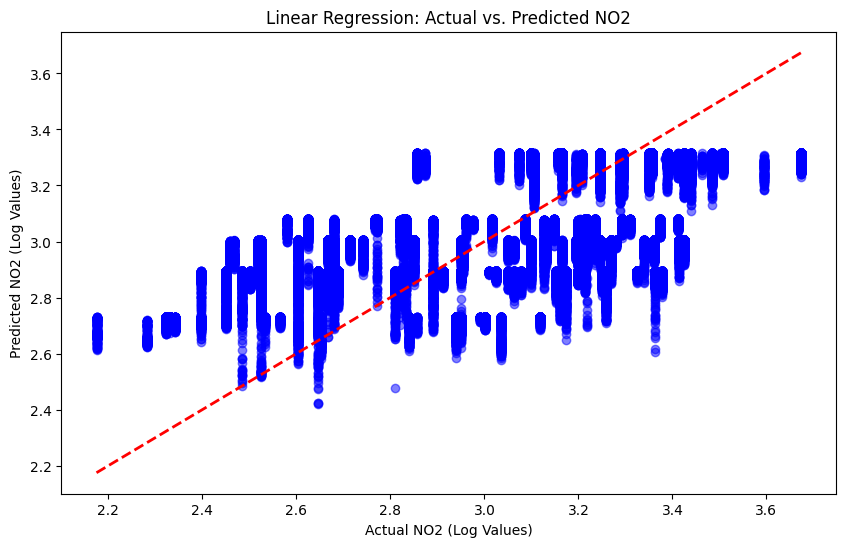

In [145]:
# Visualize the performance of the NO2 inear regression model
# Compare the actual NO2 values to the predcted NO2 values to see how well the model is performing
# A perfect model would have all the point lying on the line, which is not the case here

# Create the figure
plt.figure(figsize = (10, 6))

# Plot the actual vs predicted NO2 values as a scatter plot
plt.scatter(y_test_no2, y_pred_no2, alpha = 0.5, color = 'blue')

# Draw a red dashed line representing a perfect prediction like the y = x line
plt.plot(
        [y_test_no2.min(),y_test_no2.max()],
        [y_test_no2.min(), y_test_no2.max()],
        'r--',
        lw=2
)

# Label the x-axis as actual NO2 values which are log scaled
plt.xlabel('Actual NO2 (Log Values)')

# Label the y-axis as predicted NO2 values which are log scaled as well
plt.ylabel('Predicted NO2 (Log Values)')

# The title of the plot
plt.title('Linear Regression: Actual vs. Predicted NO2')

# Display the plot
plt.show()

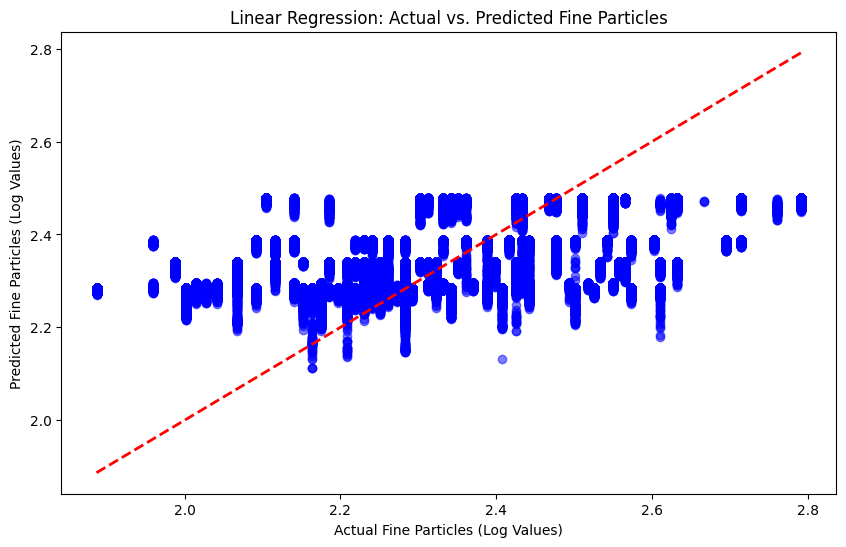

In [146]:
# Visualize the performance of the fine particles linear regression model
# Compare the actual fine particle values to the predicted values to see how accurate the model is
# The closer the points are to the line, the better the model is performing

# Create the figure
plt.figure(figsize = (10, 6))

# Plot the actual vs predicted fine particle values as a scatter plot
plt.scatter(y_test_particles, y_pred_particles, alpha = 0.5, color = 'blue')

# Draw a red dashed line representing the perfect prediction like the y = x line
plt.plot(
        [y_test_particles.min(), y_test_particles.max()],
        [y_test_particles.min(), y_test_particles.max()],
        'r--',
        lw=2
    )

# Label the x-axis as actual fine particle values which are log scaled
plt.xlabel('Actual Fine Particles (Log Values)')

# Label the y-axis as predicted fine particle values which are log scaled as well
plt.ylabel('Predicted Fine Particles (Log Values)')

# The title of the plot
plt.title('Linear Regression: Actual vs. Predicted Fine Particles')

# Display the plot
plt.show()

In [147]:
# Analyze the performance of both the linear regression models
# Use regression metrics like r2, RMSE, MAE, and MAPE to see how accurate
# our NO2 and fine particle predictions are compared to the actual values

# Import the evaluation metrics from sklearn
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

### NO2 model evaluation

# Calculate the r-squared value to see how well he model explains the variance in the NO2 data
r2_no2 = r2_score(y_test_no2, y_pred_no2)

# Calculate the RMSE to see the average prediction error magnitude, and it penalizes large errors more
rmse_no2 = np.sqrt(mean_squared_error(y_test_no2, y_pred_no2))

# Calculate the MAE to see the average absolute error between predicted and actual NO2 values
mae_no2 = mean_absolute_error(y_test_no2, y_pred_no2)

# Calculate the MAPE to see the percentage based error measurements for the predicted and actual NO2 values
mape_no2 = np.mean(np.abs((y_test_no2 - y_pred_no2) / y_test_no2)) * 100

# Print the NO2 model performance results
print("NO2 Linear Regression Model Performance:")

# Model fit quality
print(f"R-squared : {r2_no2:.3f}")

# Error size
print(f"RMSE : {rmse_no2:.3f}")

# Average error
print(f"MAE : {mae_no2:.3f}  (high precision due to log scale)")

# Percentage error
print(f"MAPE : {mape_no2:.3f}%  (high precision due to log scale)")

# Blank line to seperate them apart
print()

### Fine particles model evaluation

# Calculate the r-squared values for the fine particles model
r2_particles = r2_score(y_test_particles, y_pred_particles)

# Calculate the RMSE for the fine particles model
rmse_particles = np.sqrt(mean_squared_error(y_test_particles, y_pred_particles))

# Calculate the MAE for the fine particles model
mae_particles = mean_absolute_error(y_test_particles, y_pred_particles)

# Calculate the MAPE for the fine particles model
mape_particles = np.mean(np.abs((y_test_particles - y_pred_particles) / y_test_particles)) * 100

# Print fine particles model performance results
print("Fine Particles Linear Regression Model Performance:")

# Model fit quality
print(f"R-squared : {r2_particles:.3f}")

# Error size
print(f"RMSE : {rmse_particles:.3f}")

# Average error
print(f"MAE : {mae_particles:.3f}  (high precision due to log scale)")

# Percentage error
print(f"MAPE : {mape_particles:.3f}%  (high precision due to log scale)")

NO2 Linear Regression Model Performance:
R-squared : 0.289
RMSE : 0.262
MAE : 0.224  (high precision due to log scale)
MAPE : 7.677%  (high precision due to log scale)

Fine Particles Linear Regression Model Performance:
R-squared : 0.140
RMSE : 0.171
MAE : 0.141  (high precision due to log scale)
MAPE : 6.088%  (high precision due to log scale)


Time Series Analysis

In [148]:
# Prepare the dataset specifically for the time-series analysis
# Extract the relevant columns, make a proper datetime idnex using Year and month
# and organize the data so it can be used for time-based modeling and visuals

# Make a new dataframe with only the necessary columns for time-series analysis
df_pt = df_main[['Year','Month', 'Borough', 'Fine_Particles_Log', 'Traffic_Volume_Log']].copy()

# Combine the Year and Month into a single datetime column so we can treat the data as a time series
df_pt['Date'] = pd.to_datetime(
    df_pt['Year'].astype(str) + '-' + \
    df_pt['Month'].astype(str)
)

# Set the new Date column as the index for the time-based operations
df_pt = df_pt.set_index('Date')

# Drop the original Year and Month columns as they are not part of the Date index
df_pt = df_pt.drop(columns=['Year', 'Month'])

# Sort the dataframe by the Date index to make sure it is in proper chronological order
df_pt = df_pt.sort_index()

# Dispaly the first few rows to make sure that everything looks correct
df_pt.head()


,Borough,Fine_Particles_Log,Traffic_Volume_Log
Date,,,
2009-01-01,Manhattan,2.791165,4.718499
2009-01-01,Manhattan,2.791165,1.791759
2009-01-01,Manhattan,2.791165,4.276666
2009-01-01,Manhattan,2.791165,4.465908
2009-01-01,Manhattan,2.791165,1.791759


In [149]:
# Prepare the NO2 and traffic dataset for the time-series analysis

# Make a new dataframe with only the needed columns for NO2 and traffic analysis
df_n2t = df_main[['Month', 'Year', 'Borough', 'NO2_Log', 'Traffic_Volume_Log']].copy()

# Combine the Year and Month into a single datatime column so that it can be used for time-based analysis
df_n2t['Date'] = pd.to_datetime(
    df_n2t['Year'].astype(str) + '-' + \
    df_n2t['Month'].astype(str)
)

# Set the date column as the index so the dataframe is structured for time-series analysis
df_n2t = df_n2t.set_index('Date')

# Drop the original Year and Month columns since they are now indluced in the Date index
df_n2t = df_n2t.drop(columns=['Year', 'Month'])

# Sort the dataframe by the Date index to make sure everything is in chronological order
df_n2t = df_n2t.sort_index()

# Print out the first few rows to see if everything looks fined
df_n2t.head()

,Borough,NO2_Log,Traffic_Volume_Log
Date,,,
2009-01-01,Manhattan,3.673766,4.718499
2009-01-01,Manhattan,3.673766,1.791759
2009-01-01,Manhattan,3.673766,4.276666
2009-01-01,Manhattan,3.673766,4.465908
2009-01-01,Manhattan,3.673766,1.791759


In [150]:
# Group the data by Date and Borough and take the average values

# Group the fine particles dataset by Date and Borough, then calculate the mean for each of the groups
df_pt = df_pt.groupby(['Date', 'Borough']).mean()

# Do the same grouping and averaging for the NO2 and traffic dataset
df_n2t = df_n2t.groupby(['Date', 'Borough']).mean()

# Display the first 20 rows to check the grouped results
df_n2t.head(20)

NO2_Log  Traffic_Volume_Log
Date       Borough                                    
2009-01-01 Brooklyn       3.414443            2.813895
           Manhattan      3.673766            3.491297
           Queens         3.363842            3.650246
2009-02-01 Bronx          3.411148            3.769312
           Brooklyn       3.414443            2.782507
           Manhattan      3.673766            3.404545
           Queens         3.363842            2.505067
           Staten Island  3.117950            0.883437
2009-06-01 Brooklyn       3.049273            3.325778
           Queens         2.949688            3.959114
           Staten Island  2.653242            3.579597
2009-07-01 Brooklyn       3.049273            3.203744
           Queens         2.949688            3.099633
           Staten Island  2.653242            2.784583
2009-08-01 Brooklyn       3.049273            3.681191
           Manhattan      3.462606            4.746404
           Queens         2.949688            1.499973
2009-12-01 Bronx          3.411148            2.810059
           Brooklyn       3.414443            3.908998
           Queens         3.363842            3.437889

In [151]:
# Define date ranges and make functions to reindex each borough's data so that all boroughs
# have a consistent monthly time series

# Get the earliest and latest dates from the fine particles dataset
global_min_date_pt = df_pt.index.get_level_values('Date').min()
global_max_date_pt = df_pt.index.get_level_values('Date').max()

# Get the earliest and latest dates from the NO2 and traffic dataset 
global_min_date_n2t = df_n2t.index.get_level_values('Date').min()
global_max_date_n2t = df_n2t.index.get_level_values('Date').max()

# Function to reindex fine particles data so every borough has a complete monthly timeline
def reindex_borough_data_pt(group):
    # Get the borough name from the grouped index
    borough_name = group.index.get_level_values('Borough').unique()[0]
    #  Make a full monthly date range across the global time span
    full_date_range = pd.date_range(start=global_min_date_pt, end=global_max_date_pt, freq = 'MS')

    # Make a template dataframe with all the dates for this borough
    template_df = pd.DataFrame({'Date': full_date_range, 'Borough': borough_name})

    # Set the index so that it matches the original grouped structures
    template_df = template_df.set_index(['Date', 'Borough'])

    # Reset the index on the original group so that it can be merged properly
    group_reset = group.reset_index()

    # Merge to fill in the missing dates for the borough
    reindexed_group = pd.merge(template_df, group_reset, on = ['Date', 'Borough'], how = 'left')

    # Set the index back and sort for clean time-series structure
    reindexed_group = reindexed_group.set_index(['Date', 'Borough']).sort_index()

    # Return the completed reindexed group
    return reindexed_group

# Function to reindex NO2 and traffic data in the same way as above
def reindex_borough_data_n2t(group):
    # Get the borough name from the grouped index
    borough_name = group.index.get_level_values('Borough').unique()[0]

    # Create a montly date range for the NO2 and traffic datasets
    full_date_range = pd.date_range(start=global_min_date_n2t, end=global_max_date_n2t, freq = 'MS')

    # Create template dataframe with all the expected dates
    template_df = pd.DataFrame({'Date': full_date_range, 'Borough': borough_name})

    # Set the inex to match the grouped format
    template_df = template_df.set_index(['Date', 'Borough'])

    # Reset the original group index for merging
    group_reset = group.reset_index()

    # Merge the template with the actual data to inset the missing time points
    reindexed_group = pd.merge(template_df, group_reset, on = ['Date', 'Borough'], how = 'left')

    # Restore the index and sort it in chronological order
    reindexed_group = reindexed_group.set_index(['Date', 'Borough']).sort_index()

    # Return the final reindexed dataframe
    return reindexed_group

In [152]:
# Apply the reindexing function to each borough to make sure that
# all boroughts have a complete and consistent monthly time series

# Apply the reindexing function to each borough in the fine particles dataset
df_pt_avg_reindexed = df_pt.groupby('Borough', group_keys = False).apply(lambda x: reindex_borough_data_pt(x))

# Apply the reindexing function to each borough in the NO2 and traffic datasets
df_n2t_avg_reindexed = df_n2t.groupby('Borough', group_keys = False).apply(lambda x: reindex_borough_data_n2t(x))

# Print out the first few rows to make sure that the reindexing worked properly
df_n2t_avg_reindexed.head()

,,NO2_Log,Traffic_Volume_Log
Date,Borough,,
2009-01-01,Bronx,NaN,NaN
2009-02-01,Bronx,3.411148,3.769312
2009-03-01,Bronx,NaN,NaN
2009-04-01,Bronx,NaN,NaN
2009-05-01,Bronx,NaN,NaN


In [153]:
# Make some summary statistics and fill in missing values using linear interpolation

# Print some summary stats for the reindexed fine particles dataset
print(df_pt_avg_reindexed.describe())

# Print some summary stats for the reindexed NO2 and traffic dataset
print(df_n2t_avg_reindexed.describe())

# FIll in missing values in the fine particles dataset using linear interpolation which smooths gaps in the time series model
df_pt_avg_inter = df_pt_avg_reindexed.interpolate(method='linear')

# Fill in missing values in the NO2 and traffic dataset using linear interpolation
df_n2t_avg_inter = df_n2t_avg_reindexed.interpolate(method='linear')

# Seperate the outputs
print('\n')

# Print some summary stats after interploation for the fine particles dataset
print(df_pt_avg_inter.describe())

# Print some summary stats after interpolation for the NO2 and traffic dataset
print(df_n2t_avg_inter.describe())

       Fine_Particles_Log  Traffic_Volume_Log
count          306.000000          306.000000
mean             2.327291            3.629479
std              0.181742            0.879403
min              1.887070            0.883437
25%              2.208274            3.055395
50%              2.312535            3.716267
75%              2.461661            4.220092
max              2.791165            5.951122
          NO2_Log  Traffic_Volume_Log
count  306.000000          306.000000
mean     2.997855            3.629479
std      0.311689            0.879403
min      2.174752            0.883437
25%      2.714695            3.055395
50%      3.063391            3.716267
75%      3.246491            4.220092
max      3.673766            5.951122


       Fine_Particles_Log  Traffic_Volume_Log
count          959.000000          959.000000
mean             2.296144            3.700088
std              0.190800            0.787644
min              1.887070            0.883437
25%         

In [154]:
# Check if any missing values are still there after interpolation

# Print any remaining rows where fine particles values are still missing
print(df_pt_avg_inter[df_pt_avg_inter['Fine_Particles_Log'].isnull()])

# Print any remaining rows where NO2 values are still missing 
print(df_n2t_avg_inter[df_n2t_avg_inter['NO2_Log'].isnull()])

                    Fine_Particles_Log  Traffic_Volume_Log
Date       Borough                                        
2009-01-01 Bronx                   NaN                 NaN
                    NO2_Log  Traffic_Volume_Log
Date       Borough                             
2009-01-01 Bronx        NaN                 NaN


In [155]:
# One last cleanup step by filling in any missing values using backfill
# inside of each borough, hen see if no null values are still left

# Fill any missing values in the fine particles dataset using backfill grouped by borough
df_pt_filled = df_pt_avg_inter.groupby('Borough').bfill()

# Fill any remaining missing values in the NO2 and traffic dataset using backfill grouped by borough
df_n2t_filled = df_n2t_avg_inter.groupby('Borough').bfill()

# Print out the first few rows of the cleaned fine partciles dataset
print(df_pt_filled.head())

# Check how many missing values are still left in each columns for the fine particles dataset
print(df_pt_filled.isnull().sum())

# Print the first few rows for the cleaned NO2 and traffic dataset
print(df_n2t_filled.head())

# Check how many missing values are still left in each column for the NO2 and traffic dataset
print(df_n2t_filled.isnull().sum())

                    Fine_Particles_Log  Traffic_Volume_Log
Date       Borough                                        
2009-01-01 Bronx              2.714695            3.769312
2009-02-01 Bronx              2.714695            3.769312
2009-03-01 Bronx              2.714695            3.673387
2009-04-01 Bronx              2.714695            3.577462
2009-05-01 Bronx              2.714695            3.481536
Fine_Particles_Log    0
Traffic_Volume_Log    0
dtype: int64
                     NO2_Log  Traffic_Volume_Log
Date       Borough                              
2009-01-01 Bronx    3.411148            3.769312
2009-02-01 Bronx    3.411148            3.769312
2009-03-01 Bronx    3.411148            3.673387
2009-04-01 Bronx    3.411148            3.577462
2009-05-01 Bronx    3.411148            3.481536
NO2_Log               0
Traffic_Volume_Log    0
dtype: int64


In [156]:
#create lagged features for fine particles and traffic volume

# Make lagged features to capture how past values influence current fine particle levels

# Make a 1-month lag of fine particles with the previous time step value
df_pt_filled['Fine_Particles_Log_Lag1'] = df_pt_filled['Fine_Particles_Log'].shift(1)

# Make a 12-month lag of fine particles with the previous time step value
df_pt_filled['Fine_Particles_Log_Lag12'] = df_pt_filled['Fine_Particles_Log'].shift(12)

# Make a 1 month lag of traffic volume with the previous time step value
df_pt_filled['Traffic_Volume_Log_Lag1'] = df_pt_filled['Traffic_Volume_Log'].shift(1)

# Make a 12-month lag of traffic volume with the previous time step value
df_pt_filled['Traffic_Volume_Log_Lag12'] = df_pt_filled['Traffic_Volume_Log'].shift(12)

# Print the first couple rows to see that the lag features were correctly added
df_pt_filled.head(15)

,,Fine_Particles_Log,Traffic_Volume_Log,Fine_Particles_Log_Lag1,Fine_Particles_Log_Lag12,Traffic_Volume_Log_Lag1,Traffic_Volume_Log_Lag12
Date,Borough,,,,,,
2009-01-01,Bronx,2.714695,3.769312,NaN,NaN,NaN,NaN
2009-02-01,Bronx,2.714695,3.769312,2.714695,NaN,3.769312,NaN
2009-03-01,Bronx,2.714695,3.673387,2.714695,NaN,3.769312,NaN
2009-04-01,Bronx,2.714695,3.577462,2.714695,NaN,3.673387,NaN
2009-05-01,Bronx,2.714695,3.481536,2.714695,NaN,3.577462,NaN
2009-06-01,Bronx,2.714695,3.385611,2.714695,NaN,3.481536,NaN
2009-07-01,Bronx,2.714695,3.289685,2.714695,NaN,3.385611,NaN
2009-08-01,Bronx,2.714695,3.193760,2.714695,NaN,3.289685,NaN
2009-09-01,Bronx,2.714695,3.097835,2.714695,NaN,3.193760,NaN


In [157]:
# Make lagged features for NO2 and traffic volume to capture the past trends over time

# Make a 1-month lag of NO2 with the previous time step value
df_n2t_filled['NO2_Log_Lag1'] = df_n2t_filled['NO2_Log'].shift(1)

# Make a 12-month lag of NO2 with the previous time step value
df_n2t_filled['NO2_Log_Lag12'] = df_n2t_filled['NO2_Log'].shift(12)

# Make a 1-month lag of traffic volume with the previous time step value
df_n2t_filled['Traffic_Volume_Log_Lag1'] = df_n2t_filled['Traffic_Volume_Log'].shift(1)

# Make a 12-month lag of traffic volume with the previous time step value
df_n2t_filled['Traffic_Volume_Log_Lag12'] = df_n2t_filled['Traffic_Volume_Log'].shift(12)

# Print out the first few rows to make sure that the lag features were added
df_n2t_filled.head()

,,NO2_Log,Traffic_Volume_Log,NO2_Log_Lag1,NO2_Log_Lag12,Traffic_Volume_Log_Lag1,Traffic_Volume_Log_Lag12
Date,Borough,,,,,,
2009-01-01,Bronx,3.411148,3.769312,NaN,NaN,NaN,NaN
2009-02-01,Bronx,3.411148,3.769312,3.411148,NaN,3.769312,NaN
2009-03-01,Bronx,3.411148,3.673387,3.411148,NaN,3.769312,NaN
2009-04-01,Bronx,3.411148,3.577462,3.411148,NaN,3.673387,NaN
2009-05-01,Bronx,3.411148,3.481536,3.411148,NaN,3.577462,NaN


In [158]:
# Fill missing values created from lag feature using backfill withing each borough

# List of all the lagged feature columns that may have NaN values after shifting
lagged_pt_cols = ['Fine_Particles_Log_Lag1', 'Fine_Particles_Log_Lag12', 'Traffic_Volume_Log_Lag1', 'Traffic_Volume_Log_Lag12']

# Loop through each lagged column and fill missing values using backfill grouped by borough
for col in lagged_pt_cols:
    df_pt_filled[col] = df_pt_filled.groupby('Borough')[col].bfill()

In [159]:
# Fill missing values created from NO2 and traffic lag features using backfill in each borough

# List of all the lagged feature columns that may have NaN values after shifting
lagged_pt_cols = ['NO2_Log_Lag1', 'NO2_Log_Lag12', 'Traffic_Volume_Log_Lag1', 'Traffic_Volume_Log_Lag12']

# Loop through each lagged column and fill missing values using backfill grouped by borough
for col in lagged_pt_cols:
    df_n2t_filled[col] = df_n2t_filled.groupby('Borough')[col].bfill()

In [160]:
# Create time-based feature from the Date index and add cyclical encoding for the month
# Helps the model understand seasonable patterns more effectively

# Get the month from the Date index for each row
df_pt_filled['Month'] = df_pt_filled.index.get_level_values('Date').month

# Get the year from the Date index for each row
df_pt_filled['Year'] = df_pt_filled.index.get_level_values('Date').year

# Make a sine transformation of the month to get the cyclical seasonal patterns like December to January
df_pt_filled['Month_Sin'] = np.sin(2 * np.pi * df_pt_filled['Month'] / 12)

# Make a cosine transofmration of the month to complement the sine encoding for the entire cycle
df_pt_filled['Month_Cos'] = np.cos(2 * np.pi * df_pt_filled['Month'] / 12)

# Display the fir few rows to make sure tha tthe new time features were added properly
df_pt_filled.head()

,,Fine_Particles_Log,Traffic_Volume_Log,Fine_Particles_Log_Lag1,Fine_Particles_Log_Lag12,Traffic_Volume_Log_Lag1,Traffic_Volume_Log_Lag12,Month,Year,Month_Sin,Month_Cos
Date,Borough,,,,,,,,,,
2009-01-01,Bronx,2.714695,3.769312,2.714695,2.714695,3.769312,3.769312,1,2009,0.500000,8.660254e-01
2009-02-01,Bronx,2.714695,3.769312,2.714695,2.714695,3.769312,3.769312,2,2009,0.866025,5.000000e-01
2009-03-01,Bronx,2.714695,3.673387,2.714695,2.714695,3.769312,3.769312,3,2009,1.000000,6.123234e-17
2009-04-01,Bronx,2.714695,3.577462,2.714695,2.714695,3.673387,3.769312,4,2009,0.866025,-5.000000e-01
2009-05-01,Bronx,2.714695,3.481536,2.714695,2.714695,3.577462,3.769312,5,2009,0.500000,-8.660254e-01


In [161]:
# Make time-based features for the NO2 and traffic volume datasets
# Also use cyclical encoding to the month feature to better capture all of the seasonal patterns

# Get the month from the date index for each row
df_n2t_filled['Month'] = df_n2t_filled.index.get_level_values('Date').month

# Get the year from the date index for each row
df_n2t_filled['Year'] = df_n2t_filled.index.get_level_values('Date').year

# Make the sine encoding of month to get the cclical seasonal behavior
# Little note that the end of year wraps to the start
df_n2t_filled['Month_Sin'] = np.sin(2 * np.pi * df_n2t_filled['Month'] / 12)

# Make the cosine encoding of month to complement the sine encoding for the entire cycle to complete sine
df_n2t_filled['Month_Cos'] = np.cos(2 * np.pi * df_n2t_filled['Month'] / 12)

# Display the first few rows to make sure that the new time features were added properly
df_n2t_filled.head()

,,NO2_Log,Traffic_Volume_Log,NO2_Log_Lag1,NO2_Log_Lag12,Traffic_Volume_Log_Lag1,Traffic_Volume_Log_Lag12,Month,Year,Month_Sin,Month_Cos
Date,Borough,,,,,,,,,,
2009-01-01,Bronx,3.411148,3.769312,3.411148,3.411148,3.769312,3.769312,1,2009,0.500000,8.660254e-01
2009-02-01,Bronx,3.411148,3.769312,3.411148,3.411148,3.769312,3.769312,2,2009,0.866025,5.000000e-01
2009-03-01,Bronx,3.411148,3.673387,3.411148,3.411148,3.769312,3.769312,3,2009,1.000000,6.123234e-17
2009-04-01,Bronx,3.411148,3.577462,3.411148,3.411148,3.673387,3.769312,4,2009,0.866025,-5.000000e-01
2009-05-01,Bronx,3.411148,3.481536,3.411148,3.411148,3.577462,3.769312,5,2009,0.500000,-8.660254e-01


In [162]:
# Make rolling window feature to capture the short-term and long-term trends
# in both fine particle levels and traffic volume

# Make different rolling window sizes to capture the multiple time scales which are short, medium, and long term
rolling_windows = [3,6,12]

# Loop through each window size and make rolling statistics
for window in rolling_windows:
    # Make a descrpitive column name for rolling mean of the fine particles
    particle_column_name = f'Fine_Particle_RollMean{window}'

    # Make a descriptive column name for rolling standard deviation of the traffic volume
    traffic_column_name = f'Traffic_Volume_RollStd{window}'

    # Calculate the rolling mean of the fine particles for each borough
    df_pt_filled[particle_column_name] = df_pt_filled.groupby('Borough')['Fine_Particles_Log'].rolling(window=window).mean().reset_index(level = 0, drop = True)

    # Calculate the rolling standard deviation of the traffic volume for each borough
    df_pt_filled[traffic_column_name] = df_pt_filled.groupby('Borough')['Traffic_Volume_Log'].rolling(window=window).std().reset_index(level = 0, drop = True)

# Display the first few rows to check that the rolling features were created properly
df_pt_filled.head()

,,Fine_Particles_Log,Traffic_Volume_Log,Fine_Particles_Log_Lag1,Fine_Particles_Log_Lag12,Traffic_Volume_Log_Lag1,Traffic_Volume_Log_Lag12,Month,Year,Month_Sin,Month_Cos,Fine_Particle_RollMean3,Traffic_Volume_RollStd3,Fine_Particle_RollMean6,Traffic_Volume_RollStd6,Fine_Particle_RollMean12,Traffic_Volume_RollStd12
Date,Borough,,,,,,,,,,,,,,,,
2009-01-01,Bronx,2.714695,3.769312,2.714695,2.714695,3.769312,3.769312,1,2009,0.500000,8.660254e-01,NaN,NaN,NaN,NaN,NaN,NaN
2009-02-01,Bronx,2.714695,3.769312,2.714695,2.714695,3.769312,3.769312,2,2009,0.866025,5.000000e-01,NaN,NaN,NaN,NaN,NaN,NaN
2009-03-01,Bronx,2.714695,3.673387,2.714695,2.714695,3.769312,3.769312,3,2009,1.000000,6.123234e-17,2.714695,0.055383,NaN,NaN,NaN,NaN
2009-04-01,Bronx,2.714695,3.577462,2.714695,2.714695,3.673387,3.769312,4,2009,0.866025,-5.000000e-01,2.714695,0.095925,NaN,NaN,NaN,NaN
2009-05-01,Bronx,2.714695,3.481536,2.714695,2.714695,3.577462,3.769312,5,2009,0.500000,-8.660254e-01,2.714695,0.095925,NaN,NaN,NaN,NaN


In [163]:
# Make rolling window features for NO2 and traffic volume
# to capture short-term and long-term trends within each borough

# Rolling window sizes to get the different time scales like 3, 6, and 12 months
rolling_windows = [3,6,12]

# Loop through each window size and make rolling statistics
for window in rolling_windows:
    # Make a descriptive column name for rolling mean of the NO2
    no2_column_name = f'NO2_RollMean{window}'
    
    # Make a descriptive column name for rolling standard deviation of the traffic volume
    traffic_column_name = f'Traffic_Volume_RollStd{window}'

    # Compute the rolling mean of NO2 values grouped by borough
    df_n2t_filled[no2_column_name] = df_n2t_filled.groupby('Borough')['NO2_Log'].rolling(window=window).mean().reset_index(level = 0, drop = True)

    # Compute the rolling standard deviation of traffic volume values grouped by borough
    df_n2t_filled[traffic_column_name] = df_n2t_filled.groupby('Borough')['Traffic_Volume_Log'].rolling(window=window).std().reset_index(level = 0, drop = True)

# Display the first few rows to make sure that rolling features were added properly
df_n2t_filled.head()

,,NO2_Log,Traffic_Volume_Log,NO2_Log_Lag1,NO2_Log_Lag12,Traffic_Volume_Log_Lag1,Traffic_Volume_Log_Lag12,Month,Year,Month_Sin,Month_Cos,NO2_RollMean3,Traffic_Volume_RollStd3,NO2_RollMean6,Traffic_Volume_RollStd6,NO2_RollMean12,Traffic_Volume_RollStd12
Date,Borough,,,,,,,,,,,,,,,,
2009-01-01,Bronx,3.411148,3.769312,3.411148,3.411148,3.769312,3.769312,1,2009,0.500000,8.660254e-01,NaN,NaN,NaN,NaN,NaN,NaN
2009-02-01,Bronx,3.411148,3.769312,3.411148,3.411148,3.769312,3.769312,2,2009,0.866025,5.000000e-01,NaN,NaN,NaN,NaN,NaN,NaN
2009-03-01,Bronx,3.411148,3.673387,3.411148,3.411148,3.769312,3.769312,3,2009,1.000000,6.123234e-17,3.411148,0.055383,NaN,NaN,NaN,NaN
2009-04-01,Bronx,3.411148,3.577462,3.411148,3.411148,3.673387,3.769312,4,2009,0.866025,-5.000000e-01,3.411148,0.095925,NaN,NaN,NaN,NaN
2009-05-01,Bronx,3.411148,3.481536,3.411148,3.411148,3.577462,3.769312,5,2009,0.500000,-8.660254e-01,3.411148,0.095925,NaN,NaN,NaN,NaN


In [164]:
# Fill missing valus make by rolling window calculations using backfill in each borough

# List of rolling featur ecolumsn that may have NaN values due to window calculations
rolling_pt_cols = ['Fine_Particle_RollMean3', 'Fine_Particle_RollMean6', 'Fine_Particle_RollMean12', 'Traffic_Volume_RollStd3', 'Traffic_Volume_RollStd6', 'Traffic_Volume_RollStd12']

# Loop through each rolling feature and fill missing values using backfill grouped by borough
for col in rolling_pt_cols:
    df_pt_filled[col] = df_pt_filled.groupby('Borough')[col].bfill()

In [165]:
# Quick little preview of the updated dataframe to make sre all of the rolling features and preprocessing
# steps were applied properly

# Display the first few rows of the final processed fine particles dataset
df_pt_filled.head()

,,Fine_Particles_Log,Traffic_Volume_Log,Fine_Particles_Log_Lag1,Fine_Particles_Log_Lag12,Traffic_Volume_Log_Lag1,Traffic_Volume_Log_Lag12,Month,Year,Month_Sin,Month_Cos,Fine_Particle_RollMean3,Traffic_Volume_RollStd3,Fine_Particle_RollMean6,Traffic_Volume_RollStd6,Fine_Particle_RollMean12,Traffic_Volume_RollStd12
Date,Borough,,,,,,,,,,,,,,,,
2009-01-01,Bronx,2.714695,3.769312,2.714695,2.714695,3.769312,3.769312,1,2009,0.500000,8.660254e-01,2.714695,0.055383,2.714695,0.156645,2.714695,0.333447
2009-02-01,Bronx,2.714695,3.769312,2.714695,2.714695,3.769312,3.769312,2,2009,0.866025,5.000000e-01,2.714695,0.055383,2.714695,0.156645,2.714695,0.333447
2009-03-01,Bronx,2.714695,3.673387,2.714695,2.714695,3.769312,3.769312,3,2009,1.000000,6.123234e-17,2.714695,0.055383,2.714695,0.156645,2.714695,0.333447
2009-04-01,Bronx,2.714695,3.577462,2.714695,2.714695,3.673387,3.769312,4,2009,0.866025,-5.000000e-01,2.714695,0.095925,2.714695,0.156645,2.714695,0.333447
2009-05-01,Bronx,2.714695,3.481536,2.714695,2.714695,3.577462,3.769312,5,2009,0.500000,-8.660254e-01,2.714695,0.095925,2.714695,0.156645,2.714695,0.333447


In [166]:
# Fill in missing values made frmo the rolling window calculations using backfill in each borough
# for NO2 and traffic volume datasts

# List of the rolling feature columns that may have NaN values due to rolling calculations
rolling_n2t_cols = ['NO2_RollMean3', 'NO2_RollMean6', 'NO2_RollMean12', 'Traffic_Volume_RollStd3', 'Traffic_Volume_RollStd6', 'Traffic_Volume_RollStd12']

# Loop through each rolling feature column and fill missing values using backfill grouped by borough
for col in rolling_n2t_cols:
    df_n2t_filled[col] = df_n2t_filled.groupby('Borough')[col].bfill()

In [167]:
# Quick little preview of the updated dataframe to make sure all of the rolling features and preprocessing
# steps were applied properly for the NO2 and traffic volume datasets.

# Display the first few rows of the final processed NO2 and traffic volume dataset
df_n2t_filled.head()

,,NO2_Log,Traffic_Volume_Log,NO2_Log_Lag1,NO2_Log_Lag12,Traffic_Volume_Log_Lag1,Traffic_Volume_Log_Lag12,Month,Year,Month_Sin,Month_Cos,NO2_RollMean3,Traffic_Volume_RollStd3,NO2_RollMean6,Traffic_Volume_RollStd6,NO2_RollMean12,Traffic_Volume_RollStd12
Date,Borough,,,,,,,,,,,,,,,,
2009-01-01,Bronx,3.411148,3.769312,3.411148,3.411148,3.769312,3.769312,1,2009,0.500000,8.660254e-01,3.411148,0.055383,3.411148,0.156645,3.411148,0.333447
2009-02-01,Bronx,3.411148,3.769312,3.411148,3.411148,3.769312,3.769312,2,2009,0.866025,5.000000e-01,3.411148,0.055383,3.411148,0.156645,3.411148,0.333447
2009-03-01,Bronx,3.411148,3.673387,3.411148,3.411148,3.769312,3.769312,3,2009,1.000000,6.123234e-17,3.411148,0.055383,3.411148,0.156645,3.411148,0.333447
2009-04-01,Bronx,3.411148,3.577462,3.411148,3.411148,3.673387,3.769312,4,2009,0.866025,-5.000000e-01,3.411148,0.095925,3.411148,0.156645,3.411148,0.333447
2009-05-01,Bronx,3.411148,3.481536,3.411148,3.411148,3.577462,3.769312,5,2009,0.500000,-8.660254e-01,3.411148,0.095925,3.411148,0.156645,3.411148,0.333447


In [168]:
# Import a statistical test used for the time series analysis
# THis helps check whether a time series is stationary or not
# which is very important for alot of forecasting models

# Import the Augmented Dickey-Fuller test from statsmodels
from statsmodels.tsa.stattools import adfuller

In [169]:
# Run the Augmented Dickey-Fuller test on the Fine Particles dataset
# to see if the time series is stationary which is important in general for time series modeling

# Run the ADF test on the Fine_Particle_Log column
result_pt = adfuller(df_pt_filled['Fine_Particles_Log'])

# Print the ASF test statistics which is used to evaluate the stationarity of the time series
print('ADF Statistic (Fine_Particles_Log): %f' % result_pt[0])

# Print the p-value which helps see if we should reject the non-stationary hypothesis
print('p-value (Fine_Particles_Log): %f' % result_pt[1])

# Print out the critical values fo the difference confident levels
print('Critical Values:')

# Loop through and print out each critical threshold value
for key, value in result_pt[4].items():
    print('\t%s: %.3f' % (key, value))

ADF Statistic (Fine_Particles_Log): -2.829222
p-value (Fine_Particles_Log): 0.054219
Critical Values:
	1%: -3.437
	5%: -2.865
	10%: -2.568


In [170]:
# Run the Augmented Dickey-Fuller test on the NO2_Log column
# to see if the time series is stationary which is important for forecsating models

# Run the ADF test on the NO2_Log column
result_n2t = adfuller(df_n2t_filled['NO2_Log'])

# Print the ADF test statistic
print('ADF Statistic (NO2_Log): %f' % result_n2t[0])

# Print the p-value to help determine stationarity
print('p-value (NO2_Log): %f' % result_n2t[1])

# Print the critical values for different significance levels
print('Critical Values:')

# Loop through and print each critical value threshold
for key, value in result_n2t[4].items():
    print('\t%s: %.3f' % (key, value))

ADF Statistic (NO2_Log): -2.350765
p-value (NO2_Log): 0.156117
Critical Values:
	1%: -3.437
	5%: -2.865
	10%: -2.568


In [171]:
# Transform the fine particles data to make it more stationary
# used first-order differencing by subtracting the previous value

# Make a differenced version of the Fine_Particles_Log colum nto reduce the trends and staiblize the series
df_pt_filled['Fine_Particles_Log_Diff'] = df_pt_filled['Fine_Particles_Log'].diff()

In [172]:
# Make the NO2 time series more stationary by using first-order differencing, which
# helps reduce trends ands talbize the variance over time

# Make a differenced version of the NO2_Log column which is the current value minus the previous values
df_n2t_filled['NO2_Log_Diff'] = df_n2t_filled['NO2_Log'].diff()

In [173]:
# Re-run the ADF test on the differenced fine particles data
# to check if applying differneicng made the time series more stationary

# Run the ADF test on the differenced fine particles data dropping NaN from differencing
result_pt_diff = adfuller(df_pt_filled['Fine_Particles_Log_Diff'].dropna())

# Print the ADF test statiscs for the differenced series
print('ADF Statistic (Fine_Particles_Log_Diff): %f' % result_pt_diff[0])

# Print the p-value to see the stationarity of the differenced series
print('p-value (Fine_Particles_Log_Diff): %f' % result_pt_diff[1])

# Print the critical values for different confidence levels
print('Critical Values:')

# Loop through and print each critical value threshold
for key, value in result_pt_diff[4].items():
    print('\t%s: %.3f' % (key, value))

ADF Statistic (Fine_Particles_Log_Diff): -11.713051
p-value (Fine_Particles_Log_Diff): 0.000000
Critical Values:
	1%: -3.437
	5%: -2.865
	10%: -2.568


In [174]:
# Re-run the ADF test on the differenced NO2 data
# to check if applying differencing made the time series more stationary

# Run the ADF test on the differenced NO2 data dropping NaN from differencing
result_n2t_diff = adfuller(df_n2t_filled['NO2_Log_Diff'].dropna())

# Print the ADF test statistics for the differenced NO2 series
print('ADF Statistic (NO2_Log_Diff): %f' % result_n2t_diff[0])

# Print the p-value to see the stationarity of the differenced NO2 series
print('p-value (NO2_Log_Diff): %f' % result_n2t_diff[1])

# Print the critical values for different confidence levels
print('Critical Values:')

# Loop through and print each critical value threshold
for key, value in result_n2t_diff[4].items():
    print('\t%s: %.3f' % (key, value))

ADF Statistic (NO2_Log_Diff): -11.174080
p-value (NO2_Log_Diff): 0.000000
Critical Values:
	1%: -3.437
	5%: -2.865
	10%: -2.568


In [175]:
# Check the stationary of the Traffic_Volume_Log series
# in the fine particles dataset using the Augmented Dickey-Fuller test ADF test

# Run the ADF test on the Traffic_Volume_Log column
result_traffic_pt = adfuller(df_pt_filled['Traffic_Volume_Log'])

# Print the ADF test statistic for traffic volume
print('ADF Statistic (Traffic_Volume_Log in df_pt_filled): %f' % result_traffic_pt[0])
# Print the p-value for traffic volume to help see whether the series is stationary or not
print('p-value (Traffic_Volume_Log in df_pt_filled): %f' % result_traffic_pt[1])

# Print the critical values for different confidence levels
print('Critical Values:')

# Loop through and print each critical value threshold
for key, value in result_traffic_pt[4].items():
    print('\t%s: %.3f' % (key, value))

ADF Statistic (Traffic_Volume_Log in df_pt_filled): -10.082516
p-value (Traffic_Volume_Log in df_pt_filled): 0.000000
Critical Values:
	1%: -3.437
	5%: -2.865
	10%: -2.568


In [176]:
# Check the stationary of the Traffic_Volume_Log series
# in the NO2 and trafic dataset using the Augmented Dickey-Fuller test ADF test

# Run the ADF test statistic for traffic volume
result_traffic_n2t = adfuller(df_n2t_filled['Traffic_Volume_Log'])

# Print the ADF test statistc for the traffic volume
print('ADF Statistic (Traffic_Volume_Log in df_n2t_filled): %f' % result_traffic_n2t[0])
# Print the p-value for traffic volume to help see whether the series is stationary or not
print('p-value (Traffic_Volume_Log in df_n2t_filled): %f' % result_traffic_n2t[1])

# Print the critical values for different confidence levels
print('Critical Values:')

# Loop through and print each critical value threshold
for key, value in result_traffic_n2t[4].items():
    print('\t%s: %.3f' % (key, value))

ADF Statistic (Traffic_Volume_Log in df_n2t_filled): -10.082516
p-value (Traffic_Volume_Log in df_n2t_filled): 0.000000
Critical Values:
	1%: -3.437
	5%: -2.865
	10%: -2.568


In [177]:
# The target vaialbe and comput ecorrelations between the
# differenced fine particles seires and the selected feature set

# Set the target variable that we are trying to analyze/predict
target_pt = 'Fine_Particles_Log_Diff'

# The feature set to compare against the target
# Don't include the original Fine_Particles_Log since we are working with the differenced version
features_pt = [
    'Traffic_Volume_Log',
    'Fine_Particles_Log_Lag1',
    'Fine_Particles_Log_Lag12',
    'Traffic_Volume_Log_Lag1',
    'Traffic_Volume_Log_Lag12',
    'Month_Sin',
    'Month_Cos',
    'Fine_Particle_RollMean3',
    'Traffic_Volume_RollStd3',
    'Fine_Particle_RollMean6',
    'Traffic_Volume_RollStd6',
    'Fine_Particle_RollMean12',
    'Traffic_Volume_RollStd12'
]

# Make a temporary dataframe containing only the target and selected features
# and get rid of any rows with missing vaue to make sure that it has clean correlation results
correlation_df_pt = df_pt_filled[[target_pt] + features_pt].dropna()

# Compute the correlation matrix and sort the correlations to the target variable
correlations_pt = correlation_df_pt.corr()[target_pt].sort_values(ascending = False)

# Print the correlations and dont include the target's self correlation which is always 1
print(f"Correlations with {target_pt}:\n{correlations_pt.drop(target_pt)}")

Correlations with Fine_Particles_Log_Diff:
Month_Sin                   0.069752
Traffic_Volume_Log_Lag12    0.067989
Traffic_Volume_Log_Lag1     0.066466
Traffic_Volume_Log          0.001654
Fine_Particle_RollMean3    -0.012398
Traffic_Volume_RollStd3    -0.013581
Fine_Particle_RollMean12   -0.040515
Traffic_Volume_RollStd12   -0.046965
Fine_Particle_RollMean6    -0.058746
Month_Cos                  -0.065189
Traffic_Volume_RollStd6    -0.069551
Fine_Particles_Log_Lag12   -0.084605
Fine_Particles_Log_Lag1    -0.125821
Name: Fine_Particles_Log_Diff, dtype: float64


In [178]:
# Define the target variable and calculate the correlations between the differenced NO2 series
# and the selected feature set

# Set the target variable that is going to be analyzed
target_n2t = 'NO2_Log_Diff'

# Define the feature set used to comapre against the target
# Exlucde the original NO2_Log from the feature set
features_n2t = [
    'Traffic_Volume_Log',
    'NO2_Log_Lag1',
    'NO2_Log_Lag12',
    'Traffic_Volume_Log_Lag1',
    'Traffic_Volume_Log_Lag12',
    'Month_Sin',
    'Month_Cos',
    'NO2_RollMean3',
    'Traffic_Volume_RollStd3',
    'NO2_RollMean6',
    'Traffic_Volume_RollStd6',
    'NO2_RollMean12',
    'Traffic_Volume_RollStd12'
]

# Make a temporary dataframe with only the target and feature columns
# Drop any NaN values to make sure everything is clean and reliable in terms of correlation calculations
correlation_df_n2t = df_n2t_filled[[target_n2t] + features_n2t].dropna()

# Compute the correlation values and sort them relative to the target variable
correlations_n2t = correlation_df_n2t.corr()[target_n2t].sort_values(ascending = False)

# Print the correlations while removing the self correlation of the target variable
print(f"Correlations with {target_n2t}:\n{correlations_n2t.drop(target_n2t)}")

Correlations with NO2_Log_Diff:
Month_Cos                   0.535865
NO2_Log_Lag12               0.063894
Traffic_Volume_RollStd6    -0.000624
Traffic_Volume_RollStd3    -0.022920
Traffic_Volume_RollStd12   -0.031914
Traffic_Volume_Log_Lag1    -0.037949
NO2_RollMean12             -0.058822
Traffic_Volume_Log_Lag12   -0.077259
NO2_RollMean3              -0.111578
Traffic_Volume_Log         -0.130341
NO2_Log_Lag1               -0.152939
NO2_RollMean6              -0.286650
Month_Sin                  -0.511838
Name: NO2_Log_Diff, dtype: float64


In [179]:
# Final feature ste for the fine particles model
# based on correlation analysis and prepare the dataset for training

# Set the target variable that we want to predict
target_pt = 'Fine_Particles_Log_Diff'

# Final selected features based on earlier correlation analysis
fine_particles_features = [
    'Fine_Particles_Log_Lag1',
    'Fine_Particles_Log_Lag12',
    'Month_Sin',
    'Month_Cos',
    'Traffic_Volume_Log_Lag1',
    'Traffic_Volume_Log_Lag12'
]

# Make the final modeling dataframe by selecting target and featuers and removing missing values
df_pt_model = df_pt_filled[[target_pt] + fine_particles_features].dropna()

# Print the shape of the dataset to make sure how many rows and columns that we are working with
print(f"Shape of df_pt_model: {df_pt_model.shape}")

# Print the first few rows to quickly see the structure and if the values are all correct
print(f"First 5 rows of df_pt_model:\n{df_pt_model.head()}")

Shape of df_pt_model: (959, 7)
First 5 rows of df_pt_model:
                    Fine_Particles_Log_Diff  Fine_Particles_Log_Lag1  \
Date       Borough                                                     
2009-02-01 Bronx                        0.0                 2.714695   
2009-03-01 Bronx                        0.0                 2.714695   
2009-04-01 Bronx                        0.0                 2.714695   
2009-05-01 Bronx                        0.0                 2.714695   
2009-06-01 Bronx                        0.0                 2.714695   

                    Fine_Particles_Log_Lag12     Month_Sin     Month_Cos  \
Date       Borough                                                         
2009-02-01 Bronx                    2.714695  8.660254e-01  5.000000e-01   
2009-03-01 Bronx                    2.714695  1.000000e+00  6.123234e-17   
2009-04-01 Bronx                    2.714695  8.660254e-01 -5.000000e-01   
2009-05-01 Bronx                    2.714695  5.000000e

In [180]:
# Define the final featuer set for the NO2 model
# and prepare the datset that will be used for training

# Set the target variable that we are trying to predict
target_n2t = 'NO2_Log_Diff'

# Final selected features based on correlation aanlysis and feature engineering
no2_features = [
    'Month_Cos',
    'Month_Sin',
    'NO2_Log_Lag1',
    'NO2_Log_Lag12',
    'Traffic_Volume_Log',
    'Traffic_Volume_Log_Lag1',
    'Traffic_Volume_Log_Lag12'
]

# Make the final modeling dataframe by choosg the target and features and dropping missing values
df_n2t_model = df_n2t_filled[[target_n2t] + no2_features].dropna()

# Print the shape of the dataset to make sure that the final size is used for modeling
print(f"Shape of df_n2t_model: {df_n2t_model.shape}")

# Print the first few rows to amke sure that everything looks good and is structured right
print(f"First 5 rows of df_n2t_model:\n{df_n2t_model.head()}")

Shape of df_n2t_model: (959, 8)
First 5 rows of df_n2t_model:
                    NO2_Log_Diff     Month_Cos     Month_Sin  NO2_Log_Lag1  \
Date       Borough                                                           
2009-02-01 Bronx             0.0  5.000000e-01  8.660254e-01      3.411148   
2009-03-01 Bronx             0.0  6.123234e-17  1.000000e+00      3.411148   
2009-04-01 Bronx             0.0 -5.000000e-01  8.660254e-01      3.411148   
2009-05-01 Bronx             0.0 -8.660254e-01  5.000000e-01      3.411148   
2009-06-01 Bronx             0.0 -1.000000e+00  1.224647e-16      3.411148   

                    NO2_Log_Lag12  Traffic_Volume_Log  \
Date       Borough                                      
2009-02-01 Bronx         3.411148            3.769312   
2009-03-01 Bronx         3.411148            3.673387   
2009-04-01 Bronx         3.411148            3.577462   
2009-05-01 Bronx         3.411148            3.481536   
2009-06-01 Bronx         3.411148            3.38

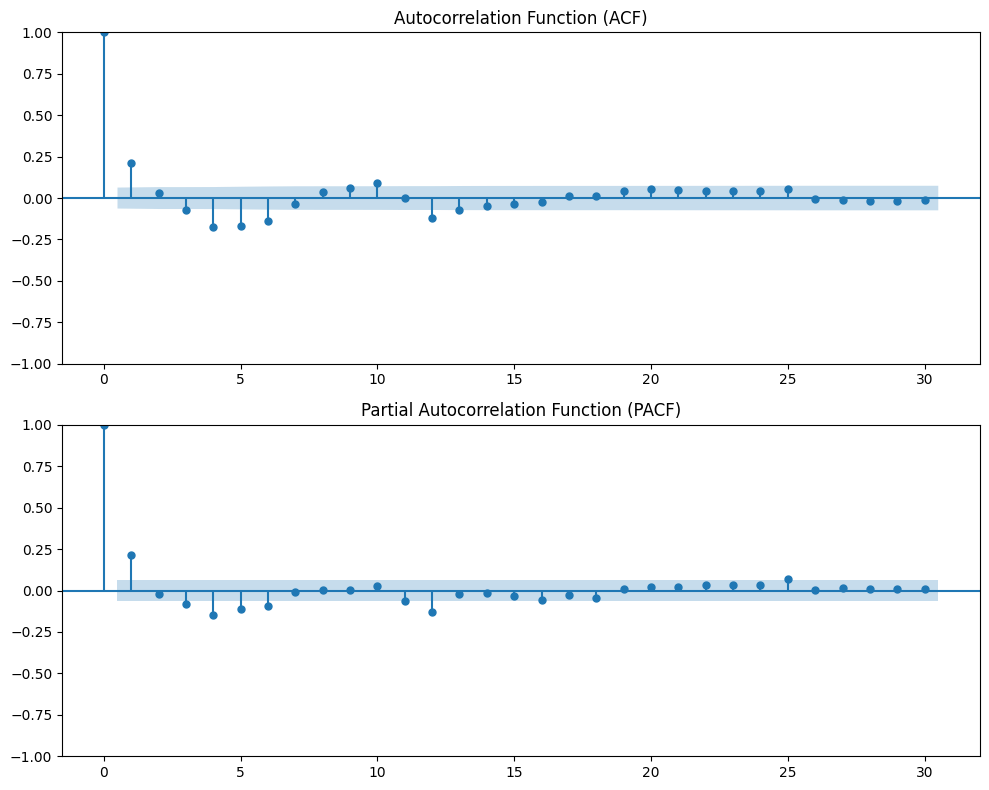

In [181]:
# Visualize the autocorrelation (ACF) and partial correlation (PACF)
# for the fine particles differenced seires to help see the temporal dependencies

# Import function for ACF and PACF plots from statsmodels
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Import matplotlib for plotting (even though we imported it earlier just looks cleaner)
import matplotlib.pyplot as plt

# Select the fine particels target series and drop any missing values left
series_to_plot = df_pt_model['Fine_Particles_Log_Diff'].dropna()

# Make a figure with two subplots one for ACF and one for PACF
fig, axes = plt.subplots(2, 1, figsize=(10, 8))

# Plot the autocorrelation function to see the overall correlation at different lags
# Same lag window for consistency
plot_acf(series_to_plot, lags = 30, ax=axes[0])
axes[0].set_title('Autocorrelation Function (ACF)')

# Plot the partial autocorrelation function to see the direct correlation at different lags relationships
# Same lag window for consistency
plot_pacf(series_to_plot, lags = 30, ax=axes[1])
axes[1].set_title('Partial Autocorrelation Function (PACF)')

# Adjust the layout so that the plots do not overlap
plt.tight_layout()

# Display the plots
plt.show()

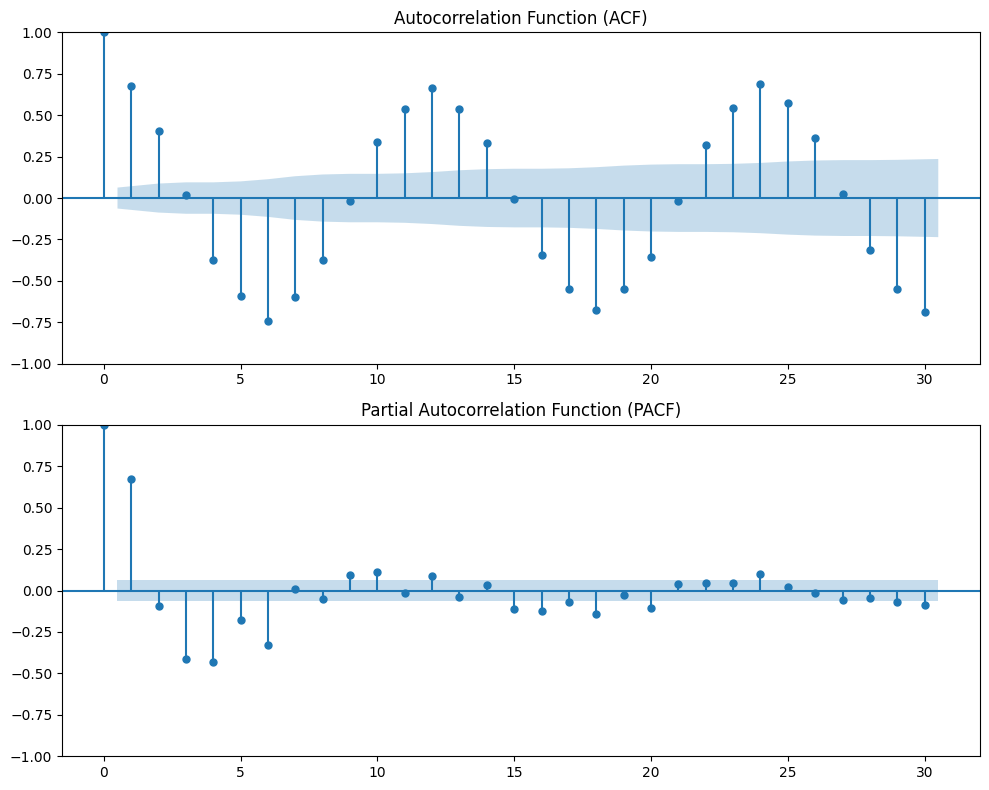

In [182]:
# Visualize the autocorrelation (ACF) and partial autocorrelation (PACF)
# for the NO2 differenced series to understand its time dependent structure

# Choose the NO2 target series and remove any missing values
series_to_plot = df_n2t_model['NO2_Log_Diff'].dropna()

# Make a figure with two subplots for ACF and PACF
fig, axes = plt.subplots(2, 1, figsize=(10, 8))

# Plot the autocorrelation function to see correlations across time lags
# Use 30 lags for consistency
plot_acf(series_to_plot, lags = 30, ax=axes[0])
axes[0].set_title('Autocorrelation Function (ACF)')

# Plot the partial autocorrelation function to see the direct correlation at different lags
# Use 30 lags for consistency
plot_pacf(series_to_plot, lags = 30, ax=axes[1])
axes[1].set_title('Partial Autocorrelation Function (PACF)')

# Prevent any overlapping things on the plot itself
plt.tight_layout()

# Display the plots
plt.show()

In [183]:
# Split the fine particles dataset into training and testing sets
# using a time-based splot to preserve the chronological order of the data

# Split ratio between training and testing data
split_ratio = 0.8

# Get all the unique dates from the dataset index
unique_dates_pt = df_pt_model.index.get_level_values('Date').unique()

# Calculate the index where the split should occur based on the ratio
split_date_index_pt = int(len(unique_dates_pt) * split_ratio)

# Get the actual date value that will beused as the split point
split_date_pt = unique_dates_pt[split_date_index_pt]

# Print the chosen split for reference
print(f"Fine Particles - Split Date: {split_date_pt}")

# Make a training feature set using data on or after the split date
X_train_pt = df_pt_model[df_pt_model.index.get_level_values('Date') < split_date_pt][fine_particles_features]

# Make a testing feature set using data on or after the split date
X_test_pt = df_pt_model[df_pt_model.index.get_level_values('Date') >= split_date_pt][fine_particles_features]

# Make a training target set using data on or after the split date
y_train_pt = df_pt_model[df_pt_model.index.get_level_values('Date') < split_date_pt][target_pt]

# Make a testing target set using data on or after the split date
y_test_pt = df_pt_model[df_pt_model.index.get_level_values('Date') >= split_date_pt][target_pt]

# Print the shapes to make sure that the split worked properly
print(f"Fine Particles - Training features shape: {X_train_pt.shape}")
print(f"Fine Particles - Testing features shape: {X_test_pt.shape}")
print(f"Fine Particles - Training target shape: {y_train_pt.shape}")
print(f"Fine Particles - Testing target shape: {y_test_pt.shape}")

Fine Particles - Split Date: 2021-11-01 00:00:00
Fine Particles - Training features shape: (769, 6)
Fine Particles - Testing features shape: (190, 6)
Fine Particles - Training target shape: (769,)
Fine Particles - Testing target shape: (190,)


In [184]:
# Split the NO2 dataset into training and testing sets
# using a time-based split to preserve the chronological order of the data

# The split_ratio is assumed to already be 0.8 which is what we did earlier

# Get all the unique dates from the dataset index
unique_dates_n2t = df_n2t_model.index.get_level_values('Date').unique()

# Calculate the index where the train/test split will occur
split_date_index_n2t = int(len(unique_dates_n2t) * split_ratio)

# Get the actual date corresponding to the split point
split_date_n2t = unique_dates_n2t[split_date_index_n2t]

# Print out the chosen split date for reference
print(f"NO2 - Split Date: {split_date_n2t}")

# Make a training feature set using data on or after the split date
X_train_n2t = df_n2t_model[df_n2t_model.index.get_level_values('Date') < split_date_n2t][no2_features]

# Make a testing feature set using data on or after the split date
X_test_n2t = df_n2t_model[df_n2t_model.index.get_level_values('Date') >= split_date_n2t][no2_features]

# Make a training target set using data on or after the split date
y_train_n2t = df_n2t_model[df_n2t_model.index.get_level_values('Date') < split_date_n2t][target_n2t]

# Make a testing target set using data on or after the split date
y_test_n2t = df_n2t_model[df_n2t_model.index.get_level_values('Date') >= split_date_n2t][target_n2t]

# Print the shapes of the training and testing sets that make sure everything worked properly
print(f"NO2 - Training features shape: {X_train_n2t.shape}")
print(f"NO2 - Testing features shape: {X_test_n2t.shape}")
print(f"NO2 - Training target shape: {y_train_n2t.shape}")
print(f"NO2 - Testing target shape: {y_test_n2t.shape}")

NO2 - Split Date: 2021-11-01 00:00:00
NO2 - Training features shape: (769, 7)
NO2 - Testing features shape: (190, 7)
NO2 - Training target shape: (769,)
NO2 - Testing target shape: (190,)


In [185]:
# We import the SARIMAX mdel, which is used for the time series forecasting
# and can handle both seasonal pattersn and external variables

# Import SARIMAX model from statsmodels for advanced time series modeling
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [186]:
# Build and train a SARIMAX model for each borough
# Forecast fine particle levels while accounting for seasonal patterns and external variables

# ARIMA order (p, d, q) for the model
order_pt = (1,1,1)

# Define the seasonal order (P, D, Q, S) for the model (12 months or the yearly seasonality)
seasonal_order_pt = (1,0, 1, 12)

# Get the unique boroughs in the dataset
unique_boroughs_pt = df_pt_model.index.get_level_values('Borough').unique()

# Dictionary to store trained models for each borough
all_borough_models_pt = {}
# Dictionary to store fitted model results for each borough
all_borough_results_pt = {}

# Define the external feature used in the model
exog_features_pt = fine_particles_features

# Loop thrugh each borough and fit a separate SARIMAX model
for borough in unique_boroughs_pt:
    # Print the status so we know which borough is being processed
    print(f"Fitting SARIMAX for Fine_Particles_Log_Diff in {borough}...")

    # Filter the dataset for the current borough
    borough_data = df_pt_model.loc[(slice(None), borough), :]
    
    # The target time series and clean index
    endog_series = borough_data['Fine_Particles_Log_Diff'].reset_index(level = 'Borough', drop = True)
    endog_series.index = pd.to_datetime(endog_series.index)
    endog_series = endog_series.asfreq('MS')

    # The exogeneous feature set and align its index
    exog_df = borough_data[exog_features_pt].reset_index(level = 'Borough', drop = True)
    exog_df.index = pd.to_datetime(exog_df.index)
    exog_df = exog_df.asfreq('MS') 

    # Define the SARIMAX model with specified parameters
    model_pt_borough = SARIMAX(
        endog=endog_series,
        exog=exog_df,
        order=order_pt,
        seasonal_order=seasonal_order_pt
    )

    # Fill the model to the data
    results_pt_borough = model_pt_borough.fit(maxiter = 1000, disp = False, low_memory = True)

    # Print the message saying it is finished for each borough
    print(f"Finished fitting for {borough}.\n")

    # Store the fitted model and results to use it later
    all_borough_models_pt[borough] = model_pt_borough
    all_borough_results_pt[borough] = results_pt_borough

Fitting SARIMAX for Fine_Particles_Log_Diff in Bronx...
Finished fitting for Bronx.

Fitting SARIMAX for Fine_Particles_Log_Diff in Brooklyn...


c:\Users\Xerouz\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
c:\Users\Xerouz\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


Finished fitting for Brooklyn.

Fitting SARIMAX for Fine_Particles_Log_Diff in Manhattan...
Finished fitting for Manhattan.

Fitting SARIMAX for Fine_Particles_Log_Diff in Queens...
Finished fitting for Queens.

Fitting SARIMAX for Fine_Particles_Log_Diff in Staten Island...
Finished fitting for Staten Island.



In [187]:
# Build and train a SARIMAX model for each borough
# Forecast NO2 levels while accounting for seasonal patterns and external variables

# ARIMA order (p, d, q) for the model
order_n2t = (1,1,1)

# Seasonal order (P, D, Q, S) for the model (12 months or the yearly seasonality)
seasonal_order_n2t = (1,0,1,12)

# Get all unique boroughs in the dataset
unique_boroughs_n2t = df_n2t_model.index.get_level_values('Borough').unique()

# Dictionary to store SARIMAX models for each borough
all_borough_models_n2t = {}
# Dictionary to store fitted model results for each borough
all_borough_results_n2t = {}

# Define the external feature used in the model
exog_features_n2t = no2_features

# Loop through each borough and fit a separate SARIMAX model
for borough in unique_boroughs_n2t:
    # Print which borough is currently being procssed
    print(f"Fitting SARIMAX for NO2_Log_Diff in {borough}...")

    # Filter the dataset for the current borough
    borough_data = df_n2t_model.loc[(slice(None), borough), :]
    
    # The endogeneous time series and clean its index
    endog_series = borough_data['NO2_Log_Diff'].reset_index(level = 'Borough', drop = True)
    endog_series.index = pd.to_datetime(endog_series.index)
    endog_series = endog_series.asfreq('MS')

    # The align  exogeneous features
    exog_df = borough_data[exog_features_n2t].reset_index(level = 'Borough', drop = True)
    exog_df.index = pd.to_datetime(exog_df.index)
    exog_df = exog_df.asfreq('MS') 

    # The SARIMAX model using both the endogeneous and exogeneous variables
    model_n2t_borough = SARIMAX(
        endog=endog_series,
        exog=exog_df,
        order=order_n2t,
        seasonal_order=seasonal_order_n2t
    )

    # Fit the model
    results_n2t_borough = model_n2t_borough.fit(maxiter = 1000, disp = False, low_memory = True)

    # Print the completion message for this borough
    print(f"Finished fitting for {borough}.\n")

    # Store the fitted model and results for this borough
    all_borough_models_n2t[borough] = model_n2t_borough
    all_borough_results_n2t[borough] = results_n2t_borough

Fitting SARIMAX for NO2_Log_Diff in Bronx...
Finished fitting for Bronx.

Fitting SARIMAX for NO2_Log_Diff in Brooklyn...
Finished fitting for Brooklyn.

Fitting SARIMAX for NO2_Log_Diff in Manhattan...
Finished fitting for Manhattan.

Fitting SARIMAX for NO2_Log_Diff in Queens...
Finished fitting for Queens.

Fitting SARIMAX for NO2_Log_Diff in Staten Island...
Finished fitting for Staten Island.



In [188]:
# Generate the SARIMAX predictions for the fine particles
# for each borough using the already trained models and the test data

# Dictionary to store predictions for each borough
all_borough_predictions_pt = {}

# Loop through each borough to generate the forecast
for borough in unique_boroughs_pt:
    # Print which borough is currently being processed
    print(f"Generating predictions for Fine_Particles_Log_Diff in {borough}...")

    # Retrive the fitted SARIMAX results for this borough
    borough_results = all_borough_results_pt[borough]

    # Get the full boough specific dataset
    borough_data = df_pt_model.loc[(slice(None), borough), :]

    # Get the exogeous test featuers starting from the split date
    borough_exog_test = borough_data[fine_particles_features].loc[split_date_pt:]

    # Make sure that the index is properly formatted as datetime
    borough_exog_test.index = pd.to_datetime(borough_exog_test.index.get_level_values('Date'))

    # Set a monthly frequency for time series forecasting
    borough_exog_test = borough_exog_test.asfreq('MS')

    # Make predictions using the fitted SARIMAX model
    borough_predictions = borough_results.predict(
        start=borough_exog_test.index[0],
        end=borough_exog_test.index[-1],
        exog=borough_exog_test
    )

    # Store the predictions for plotting later on
    all_borough_predictions_pt[borough] = borough_predictions

    # Print the completion message for each of the boroughs
    print(f"Finished predictions for {borough}.\n")

Generating predictions for Fine_Particles_Log_Diff in Bronx...
Finished predictions for Bronx.

Generating predictions for Fine_Particles_Log_Diff in Brooklyn...
Finished predictions for Brooklyn.

Generating predictions for Fine_Particles_Log_Diff in Manhattan...
Finished predictions for Manhattan.

Generating predictions for Fine_Particles_Log_Diff in Queens...
Finished predictions for Queens.

Generating predictions for Fine_Particles_Log_Diff in Staten Island...
Finished predictions for Staten Island.



In [189]:
# Generate the SARIMAX predictions for NO2
# for each borough using the trained models and corresponding test data

# Dictionary to store preidctions for each borough
all_borough_predictions_n2t = {}

# Loop through each borough to make predictions
for borough in unique_boroughs_n2t:
    print(f"Generating predictions for NO2_Log_Diff in {borough}...")

    # Get the fitted model results for this borough
    borough_results = all_borough_results_n2t[borough]

    # Filter the dataset for the current borough
    borough_data = df_n2t_model.loc[(slice(None), borough), :]

    # Get the exogeneous features for the test period for this borough
    borough_exog_test = borough_data[no2_features].loc[split_date_n2t:]

    # Convert the index to datetime for the time series consistency
    borough_exog_test.index = pd.to_datetime(borough_exog_test.index.get_level_values('Date'))

    # Use the monthly frequency
    borough_exog_test = borough_exog_test.asfreq('MS')

    # Generate thepredictions using the fitted mode
    borough_predictions = borough_results.predict(
        start=borough_exog_test.index[0],
        end=borough_exog_test.index[-1],
        exog=borough_exog_test
    )

    # Store the predictions for later visuals/plots
    all_borough_predictions_n2t[borough] = borough_predictions

    # Print the completion message for this borough
    print(f"Finished predictions for {borough}.\n")

Generating predictions for NO2_Log_Diff in Bronx...
Finished predictions for Bronx.

Generating predictions for NO2_Log_Diff in Brooklyn...
Finished predictions for Brooklyn.

Generating predictions for NO2_Log_Diff in Manhattan...
Finished predictions for Manhattan.

Generating predictions for NO2_Log_Diff in Queens...
Finished predictions for Queens.

Generating predictions for NO2_Log_Diff in Staten Island...
Finished predictions for Staten Island.



In [190]:
# Import evluations metric sfor scikit-learn
# to measure the model performacne using error based stats

# Import metrics for evluations regression models
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [191]:
# Evaluate the SARIMAX model performance for fine particles by computing
# the error metrics (MAE, MSE, RMSE) for each borough on its own

# Dictionary to store all metrics for each borough
all_borough_metrics_pt = {}

# Little status message
print("Calculating MAE, MSE, and RMSE for each borough...")

# Loop through each borough to compute the performance metrics
for borough in unique_boroughs_pt:
    # Get the actual test values for the current borough
    actual_values = y_test_pt.loc[(slice(None), borough)]

    # Make sure that the index is in the datetime format
    actual_values.index = pd.to_datetime(actual_values.index)

    # Get the predicted values for the current borough
    predicted_values = all_borough_predictions_pt[borough]

    # Align actual and predicted values by date to make sure it has the proper comparisons going on
    aligned_actual, aligned_predicted = actual_values.align(predicted_values, join = 'inner')

    # Only compute the metrics if there is overlapping data
    if not aligned_actual.empty:
        # Calculate the Mean Absolute Error
        mae = mean_absolute_error(aligned_actual, aligned_predicted)

        # Calculate the Mean Squared Error
        mse = mean_squared_error(aligned_actual, aligned_predicted)

        # Calculate the Root Mean Squared Error
        rmse = np.sqrt(mse)

        # Store metrics in dictionary
        all_borough_metrics_pt[borough] = {
            'MAE': mae,
            'MSE': mse,
            'RMSE': rmse
        }

        # Print the results for this borough
        print(f"\nMetrics for {borough}:")
        print(f"  MAE: {mae:.4f}")
        print(f"  MSE: {mse:.4f}")
        print(f"  RMSE: {rmse:.4f}")
    else:
        # Handle the case where there is no overlap between actual and predicted data
        print(f"\nNo overlapping dates for {borough} between actual and predicted values. Skipping metric calculation.")

# Print a final message
print("\nFinished calculating all metrics for all boroughs.")

Calculating MAE, MSE, and RMSE for each borough...

Metrics for Bronx:
  MAE: 0.0287
  MSE: 0.0012
  RMSE: 0.0340

Metrics for Brooklyn:
  MAE: 0.0316
  MSE: 0.0013
  RMSE: 0.0364

Metrics for Manhattan:
  MAE: 0.0142
  MSE: 0.0003
  RMSE: 0.0180

Metrics for Queens:
  MAE: 0.0278
  MSE: 0.0013
  RMSE: 0.0354

Metrics for Staten Island:
  MAE: 0.0053
  MSE: 0.0000
  RMSE: 0.0063

Finished calculating all metrics for all boroughs.


In [192]:
# Evaluate the SARIMAX models performance for NO2
# by comparing MAE, MSE, and RMSE for each borough separetely

# Dictionary to store metrics for each borough
all_borough_metrics_n2t = {}

# Print a status message so the output is easy to follow
print("Calculating MAE, MSE, and RMSE for each borough...")

# Loop throuh each borough in the dataset
for borough in unique_boroughs_n2t:
    # Get the actual test values for this borough
    actual_values = y_test_n2t.loc[(slice(None), borough)]

    # Ensure the datetime index for proper alignment
    actual_values.index = pd.to_datetime(actual_values.index)

    # Get the predicted values for this borough
    predicted_values = all_borough_predictions_n2t[borough]

    # Align the actual and predicted values by date
    aligned_actual, aligned_predicted = actual_values.align(predicted_values, join = 'inner')

    # Only compute the metrics if there is no overlapping data
    if not aligned_actual.empty:
        # Calculate the Mean Absolute Error
        mae = mean_absolute_error(aligned_actual, aligned_predicted)

        # Calculate the Mean Squared Error
        mse = mean_squared_error(aligned_actual, aligned_predicted)

        # Calculate the Root Mean Squared Error
        rmse = np.sqrt(mse)

        # Store the results for this specific borough
        all_borough_metrics_n2t[borough] = {
            'MAE': mae,
            'MSE': mse,
            'RMSE': rmse
        }

        # Print the formatted results out to the console
        print(f"\nMetrics for {borough}:")
        print(f"  MAE: {mae:.4f}")
        print(f"  MSE: {mse:.4f}")
        print(f"  RMSE: {rmse:.4f}")
    else:
        # Handle the case where there is no mathing dates
        print(f"\nNo overlapping dates for {borough} between actual and predicted values. Skipping metric calculation.")

# Print a final status message
print("\nFinished calculating all metrics for all boroughs.")

Calculating MAE, MSE, and RMSE for each borough...

Metrics for Bronx:
  MAE: 0.0294
  MSE: 0.0018
  RMSE: 0.0420

Metrics for Brooklyn:
  MAE: 0.0347
  MSE: 0.0021
  RMSE: 0.0457

Metrics for Manhattan:
  MAE: 0.0133
  MSE: 0.0003
  RMSE: 0.0180

Metrics for Queens:
  MAE: 0.0373
  MSE: 0.0020
  RMSE: 0.0445

Metrics for Staten Island:
  MAE: 0.0161
  MSE: 0.0004
  RMSE: 0.0190

Finished calculating all metrics for all boroughs.


In [193]:
# Import python's build in math module which uses common math functions like sqrt, log, etc
import math

Generating plots for all boroughs...


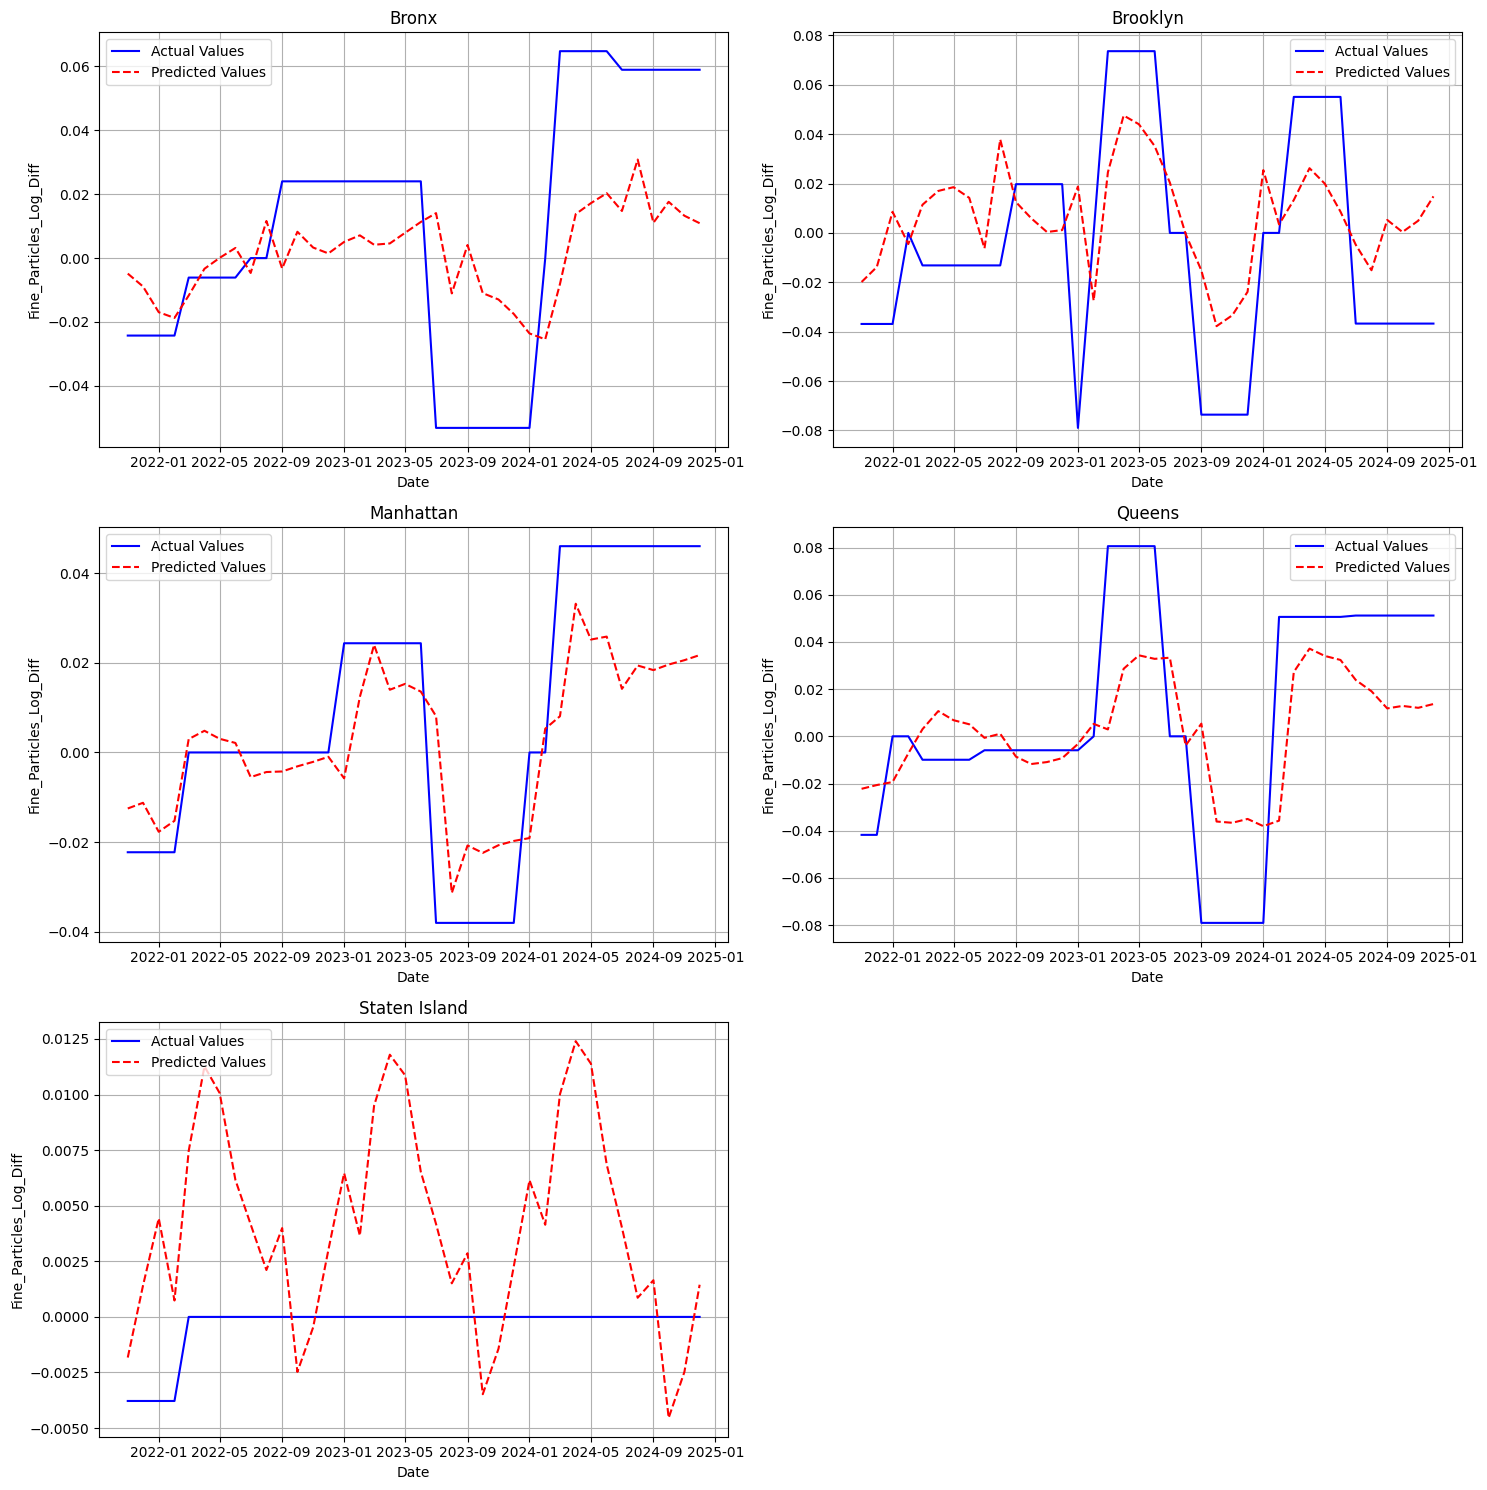

Plotting complete for all boroughs.


In [194]:
# Make comparision plots between the actual and predicted values
# for the fine particles across all brough to visually see the model's performance
print("Generating plots for all boroughs...")

# Count how many boroughts that is going to be plotted
num_boroughs_pt = len(unique_boroughs_pt)

# Get the number of rows what are needed which is 2 plots per row
rows = math.ceil(num_boroughs_pt/ 2)

# Fix the number of columns to 2 for a clean layout
cols = 2

# Create a subplot grid for all of the boroughs
fig, axes = plt.subplots(rows, cols, figsize=(15, 5 * rows), squeeze = False)

# FLatten the axes array so that we can loop through it very easily
axes = axes.flatten()

# Loop through each borough and plot the actual vs predicted values
for i, borough in enumerate(unique_boroughs_pt):
    # Choose the current subplot axis
    ax = axes[i]

    # Get the actual test values for this current borough
    actual_values_plot_pt = y_test_pt.loc[(slice(None), borough)]

    # Make sure that the dateime index for proper plotting
    actual_values_plot_pt.index = pd.to_datetime(actual_values_plot_pt.index)

    # Get the predicted values for this borough
    predicted_values_plot_pt = all_borough_predictions_pt[borough]

    # Align the actual andpredicted values by date
    aligned_actual_plot_pt, aligned_predicted_plot_pt = actual_values_plot_pt.align(predicted_values_plot_pt, join = 'inner')

    # Plot only if the data exists
    if not aligned_actual_plot_pt.empty:
        # Plot the actual values
        ax.plot(aligned_actual_plot_pt.index, aligned_actual_plot_pt.values, label='Actual Values', color='blue')

        # Plot the predicted values
        ax.plot(aligned_predicted_plot_pt.index, aligned_predicted_plot_pt.values, label='Predicted Values', color='red', linestyle='--')

        # Add a title and labels
        ax.set_title(f'{borough}')
        ax.set_xlabel('Date')
        ax.set_ylabel('Fine_Particles_Log_Diff')
        ax.legend()
        ax.grid(True)

    else:
        # Handle the case where ther eis no overlapping data
        ax.set_title(f'{borough} (No overlapping data)')
        ax.text(0.5, 0.5, 'No data to plot', horizontalalignment='center', verticalalignment='center', transform=ax.transAxes)

# Remove any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# Adjust the layout to prevent any overlapping
plt.tight_layout()

# Display the plots
plt.show()

# Print out saying the plots are outputted
print("Plotting complete for all boroughs.")

Generating plots for all boroughs...


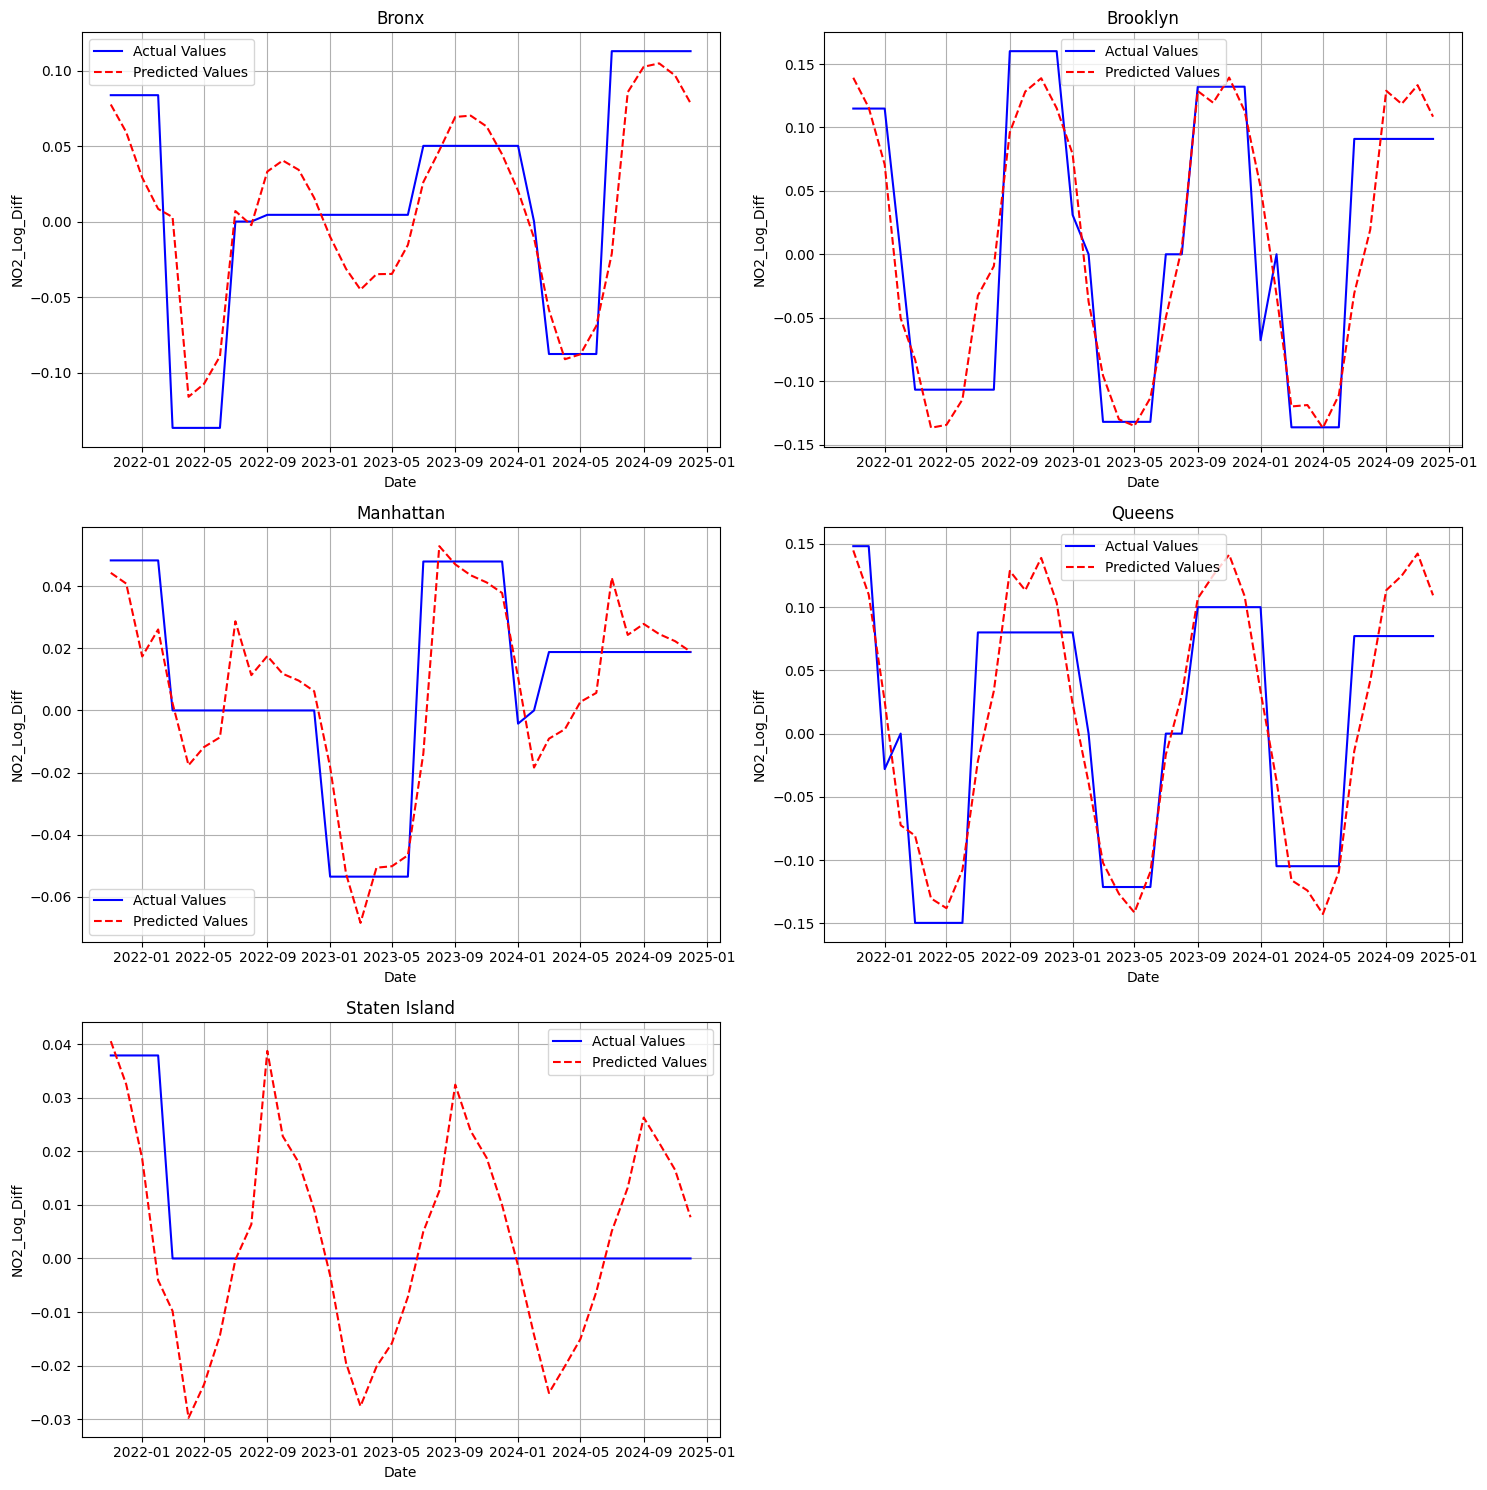

Plotting complete for all boroughs.


In [195]:
# Make plots comparing actual vs predicted NO2 values for each orough to see the SARIMAX model's performance

# Print saying that the plots are being made
print("Generating plots for all boroughs...")

# Count the number of boroughts in the dataset
num_boroughs_n2t = len(unique_boroughs_n2t)

# Calculate the number of rows needed which are 2 plots per row
rows = math.ceil(num_boroughs_n2t/ 2)

# Fix the nubmer of oclums to 2 for consistent layout
cols = 2

# Create the sbuplot grid for all of the boroughts
fig, axes = plt.subplots(rows, cols, figsize=(15, 5 * rows), squeeze = False)

# Flatten the axes array for easier looping
axes = axes.flatten()

# Loop through each boroughs and plot the results
for i, borough in enumerate(unique_boroughs_n2t):
    # Select the current subplot axis
    ax = axes[i]

    # Get the actual test valuess for this current borough
    actual_values_plot_n2t = y_test_n2t.loc[(slice(None), borough)]

    # Ensure dateime index for plotting
    actual_values_plot_n2t.index = pd.to_datetime(actual_values_plot_n2t.index)

    # Get the predicted values for this current borough
    predicted_values_plot_n2t = all_borough_predictions_n2t[borough]

    # Align actual and predicted values by their index (Date)
    aligned_actual_plot_n2t, aligned_predicted_plot_n2t = actual_values_plot_n2t.align(predicted_values_plot_n2t, join='inner')

    # Plot only if overlapping data exists
    if not aligned_actual_plot_n2t.empty:
        # Plot the actual NO2 values
        ax.plot(aligned_actual_plot_n2t.index, aligned_actual_plot_n2t.values, label='Actual Values', color='blue')

        # Plot the predicted NO2 values
        ax.plot(aligned_predicted_plot_n2t.index, aligned_predicted_plot_n2t.values, label='Predicted Values', color='red', linestyle='--')

        # Add a title and labels
        ax.set_title(f'{borough}')
        ax.set_xlabel('Date')
        ax.set_ylabel('NO2_Log_Diff')
        ax.legend()
        ax.grid(True)
    else:
        # If no overlapping data, display a message
        ax.set_title(f'{borough} (No overlapping data)')
        ax.text(0.5, 0.5, 'No data to plot', horizontalalignment='center', verticalalignment='center', transform=ax.transAxes)

# Remove any unused subplot spaces
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# Adjust the layout to prevent overlapping
plt.tight_layout()

# Dispaly the final plots
plt.show()

# Print out a final message saying that it is completed
print("Plotting complete for all boroughs.")

Generating overall NYC plot...


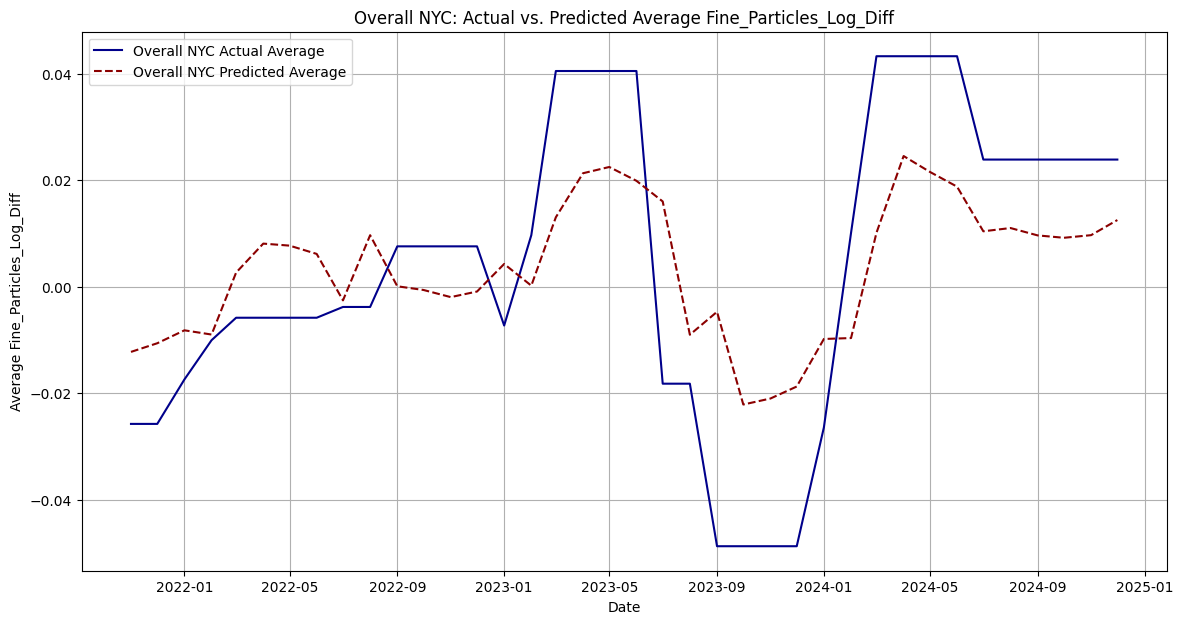

Overall NYC plotting complete.


In [196]:
# Generate an overall NYC-level plot by averaging the actual and predicted values across all boroughs
# to get a citywide trend

# Print a message saying that it has started
print("Generating overall NYC plot...")

# Compute the average actual values across all boroughs for each date
nyc_actual_avg_pt = y_test_pt.groupby(level='Date').mean()

# Make sure that the proper datetime formatting is there for plotting
nyc_actual_avg_pt.index = pd.to_datetime(nyc_actual_avg_pt.index)

# Combine all the borought predictios into a single dataframe
predicted_df_pt = pd.DataFrame(all_borough_predictions_pt)

# Compute the average prediction across boroughts for each date
nyc_predicted_avg_pt = predicted_df_pt.mean(axis=1)

# Make sure that the proper datetime formatting is there for plotting
nyc_predicted_avg_pt.index = pd.to_datetime(nyc_predicted_avg_pt.index)

# Align the actual and predicted NYC averages by date
aligned_nyc_actual_pt, aligned_nyc_predicted_pt = nyc_actual_avg_pt.align(nyc_predicted_avg_pt, join = 'inner')

# Plot only if there is overalapping data
if not aligned_nyc_actual_pt.empty:
    # Make a figure for the NYC-wide comparison
    plt.figure(figsize=(14, 7))

    # Plot the actual NYC average
    plt.plot(aligned_nyc_actual_pt.index, aligned_nyc_actual_pt.values, label = 'Overall NYC Actual Average', color = 'darkblue')

    # Plot the predicted NYC average
    plt.plot(aligned_nyc_predicted_pt.index, aligned_nyc_predicted_pt.values, label = 'Overall NYC Predicted Average', color = 'darkred', linestyle = '--')

    # Add a title and labels
    plt.title('Overall NYC: Actual vs. Predicted Average Fine_Particles_Log_Diff')
    plt.xlabel('Date')
    plt.ylabel('Average Fine_Particles_Log_Diff')
    plt.legend()
    plt.grid(True)

    # Display the plot
    plt.show()
else:
    # Handle the case where there is no overlapping dates
    print("No overlapping dates to plot for overall NYC.")

# Print a message saying that the plotting is complete
print("Overall NYC plotting complete.")

Generating overall NYC plot...


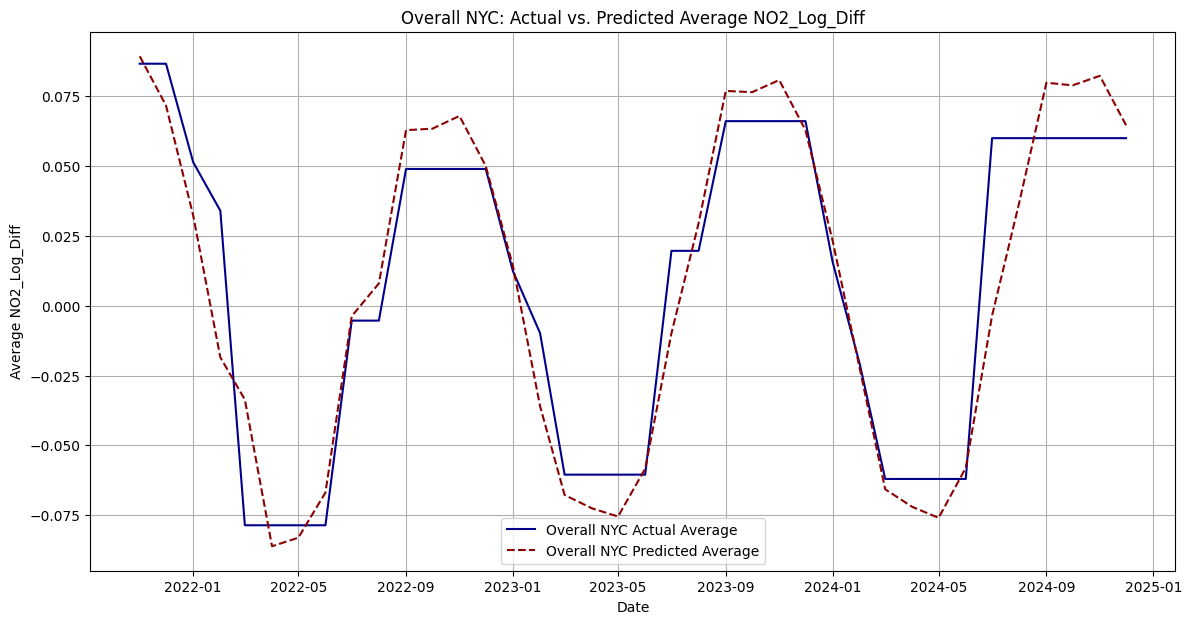

Overall NYC plotting complete.


In [197]:
# Make an overall NYC-level plot for NO2 by averaging actual and predicated values across all
# boroughs to see the citywide trend.

# Print a message saying that it has started making the plot
print("Generating overall NYC plot...")

# Compute the average actual NO2 values across all boroughs for each date
nyc_actual_avg_n2t = y_test_n2t.groupby(level = 'Date').mean()

# Convert the index to datetime for consistent plotting
nyc_actual_avg_n2t.index = pd.to_datetime(nyc_actual_avg_n2t.index)

# Combine all the borough predictions into a single dataframe
predicted_df_n2t = pd.DataFrame(all_borough_predictions_n2t)

# Compute the average predicted NO2 values across all boroughs
nyc_predicted_avg_n2t = predicted_df_n2t.mean(axis=1)

# Ensure datetime index for predictions as well
nyc_predicted_avg_n2t.index = pd.to_datetime(nyc_predicted_avg_n2t.index)

# Align actual and predicted NYC average by date
aligned_nyc_actual_n2t, aligned_nyc_predicted_n2t = nyc_actual_avg_n2t.align(nyc_predicted_avg_n2t, join = 'inner')

# Plot only if there is overlapping data
if not aligned_nyc_actual_n2t.empty:
    # Make the plot
    plt.figure(figsize=(14, 7))

    # Plot the actual NYC average NO2 values
    plt.plot(aligned_nyc_actual_n2t.index, aligned_nyc_actual_n2t.values, label = 'Overall NYC Actual Average', color = 'darkblue')

    # Plot the predicted NYC average NO2 values
    plt.plot(aligned_nyc_predicted_n2t.index, aligned_nyc_predicted_n2t.values, label = 'Overall NYC Predicted Average', color = 'darkred', linestyle='--')

    # Add labels and title
    plt.title('Overall NYC: Actual vs. Predicted Average NO2_Log_Diff')
    plt.xlabel('Date')
    plt.ylabel('Average NO2_Log_Diff')
    plt.legend()
    plt.grid(True)

    # Display the plot
    plt.show()
else:
    # Handle the case where no overlapping dates exist
    print("No overlapping dates to plot for overall NYC.")

# Print a message sayomg the process is complete
print("Overall NYC plotting complete.")

In [198]:
# Function to calculate and visualize residuals
# which is the difference between actual and predicted values for a specific borough
def plot_borough_residuals(borough_name, y_test_data, predictions_data):
    # Print which borugh is being analyzed
    print(f"Calculating and plotting residuals for {borough_name}...")

    # Get the actual test values for the selected borough
    actual_borough = y_test_data.loc[(slice(None), borough_name)]

    # Ensure the index is in the datetime format for consistent plotting
    actual_borough.index = pd.to_datetime(actual_borough.index)

    # Get the predicted values for the selected borough
    predicted_borough = predictions_data[borough_name]

    # Ensure predicted values also have a datetime index
    predicted_borough.index = pd.to_datetime(predicted_borough.index)

    # Align the actual and predicted values by date
    aligned_actual, aligned_predicted = actual_borough.align(predicted_borough, join = 'inner')

    # Go through this only if overlapping data exists
    if not aligned_actual.empty:
        # Calculate the residuals which is the difference between actual and predicted values
        residuals = aligned_actual - aligned_predicted

        # Plot the resiauls over time
        plt.figure(figsize=(12, 6))
        plt.plot(residuals.index, residuals.values, label='Residuals (Actual - Predicted)', color = 'purple', alpha = 0.7)

        # Add a horizontal reference line at zero error
        plt.axhline(0, color='black', linestyle='--', linewidth = 0.8, label = 'Zero Error Line')

        # Add labels and title
        plt.title(f'Residuals for {borough_name}: Actual vs. Predicted Fine_Particles_Log_Diff')
        plt.xlabel('Date')
        plt.ylabel('Residual Value')
        plt.legend()
        plt.grid(True)

        # Display the plot
        plt.show()

        # Print summary statistics of residuals
        print(f"\nResiduals Summary for {borough_name}:\n{residuals.describe()}")
    else:
        # Handle the case where there is no overlapping data
        print(f"No overlapping data to calculate residuals for {borough_name}.")

    # Print this message before going forward
    print(f"Residuals plotting complete for {borough_name}.")

# Example of how to use the function (you can change 'Staten Island' to any borough)
# plot_borough_residuals('Staten Island', y_test_pt, all_borough_predictions_pt)

Generating residual plots for all boroughs Fine Particles...
Calculating and plotting residuals for Bronx...


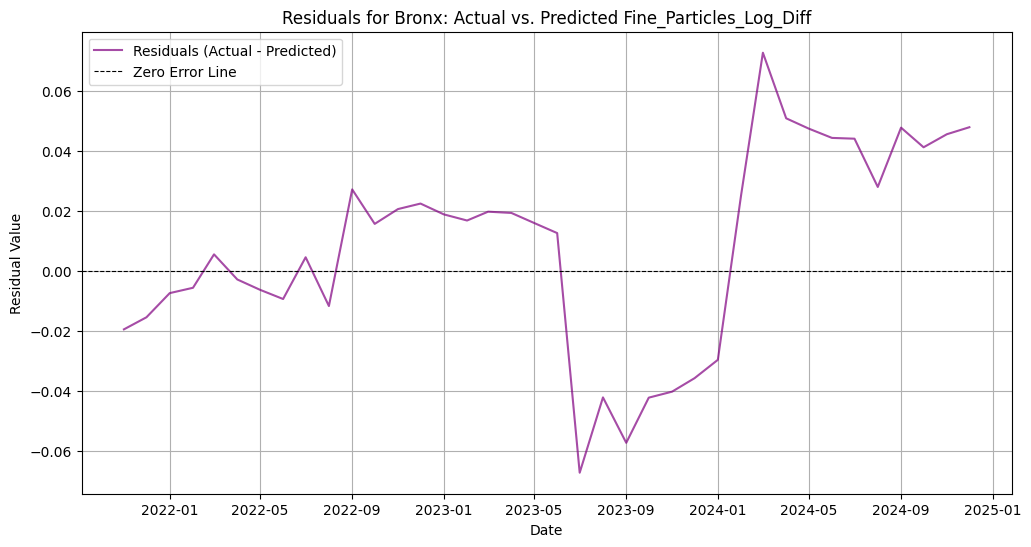


Residuals Summary for Bronx:
count    38.000000
mean      0.008042
std       0.033442
min      -0.067223
25%      -0.011032
50%       0.015953
75%       0.027898
max       0.072881
dtype: float64
Residuals plotting complete for Bronx.
Calculating and plotting residuals for Brooklyn...


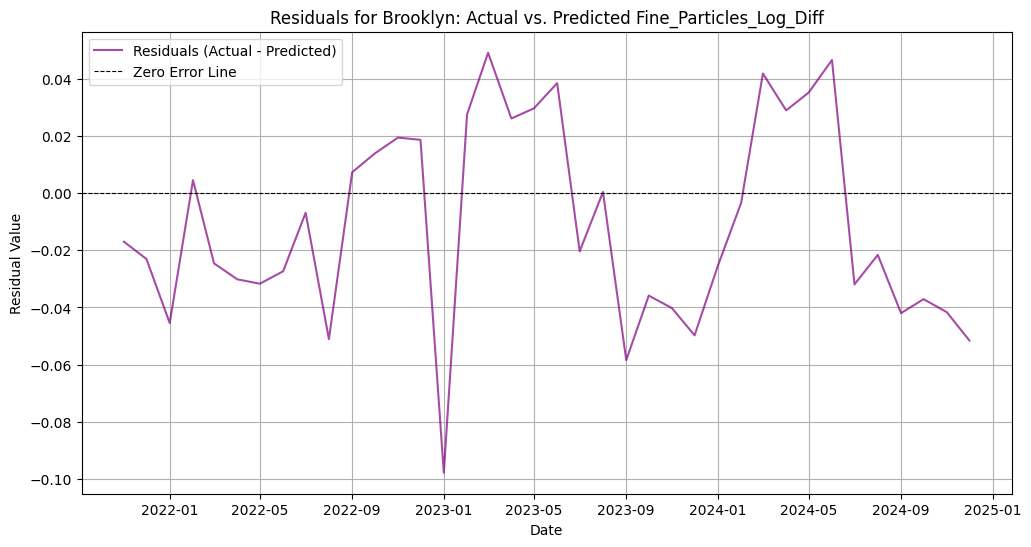


Residuals Summary for Brooklyn:
count    38.000000
mean     -0.011254
std       0.035107
min      -0.097779
25%      -0.036786
50%      -0.020999
75%       0.019189
max       0.049054
dtype: float64
Residuals plotting complete for Brooklyn.
Calculating and plotting residuals for Manhattan...


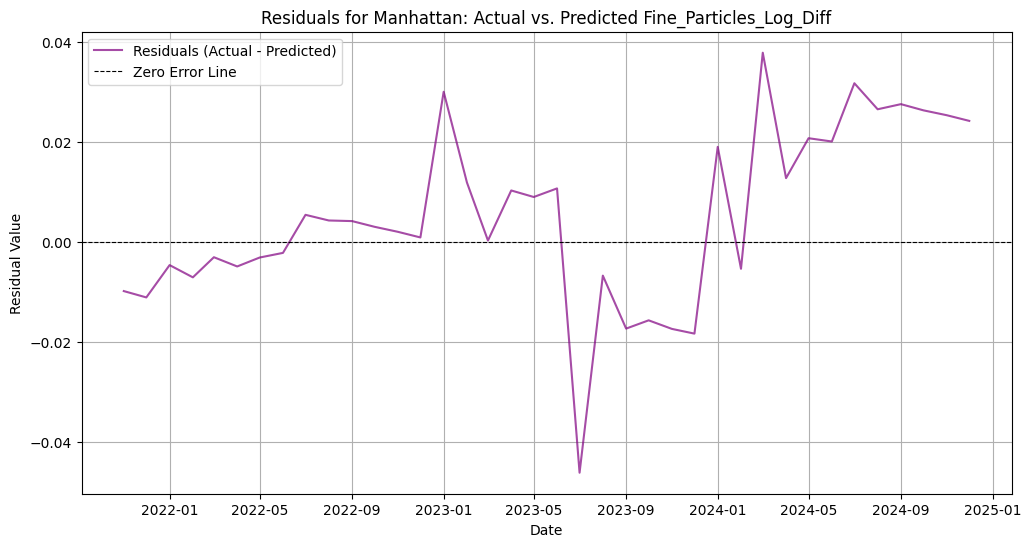


Residuals Summary for Manhattan:
count    38.000000
mean      0.005107
std       0.017534
min      -0.046089
25%      -0.005178
50%       0.003670
75%       0.019893
max       0.037919
dtype: float64
Residuals plotting complete for Manhattan.
Calculating and plotting residuals for Queens...


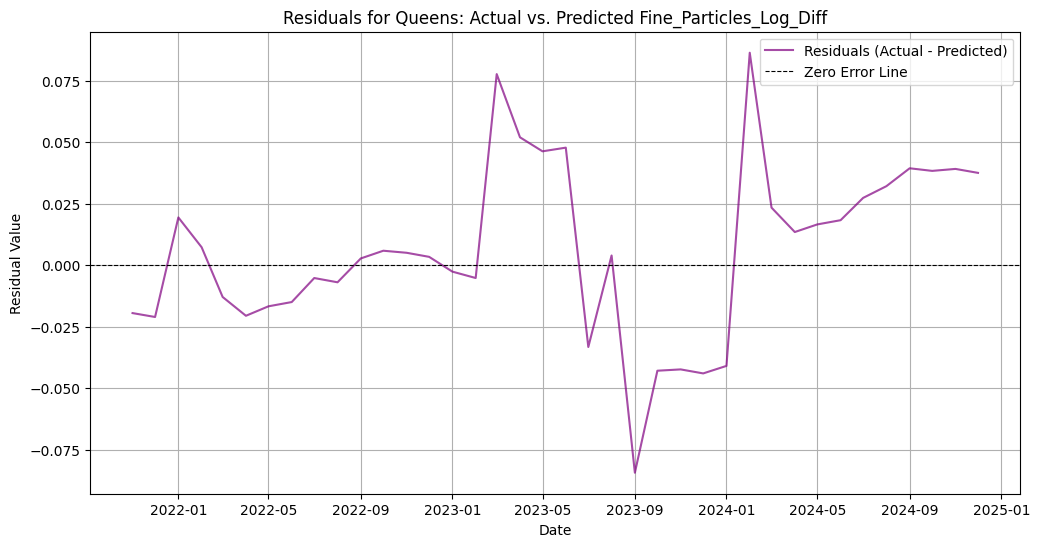


Residuals Summary for Queens:
count    38.000000
mean      0.006006
std       0.035394
min      -0.084425
25%      -0.016331
50%       0.004452
75%       0.030892
max       0.086342
dtype: float64
Residuals plotting complete for Queens.
Calculating and plotting residuals for Staten Island...


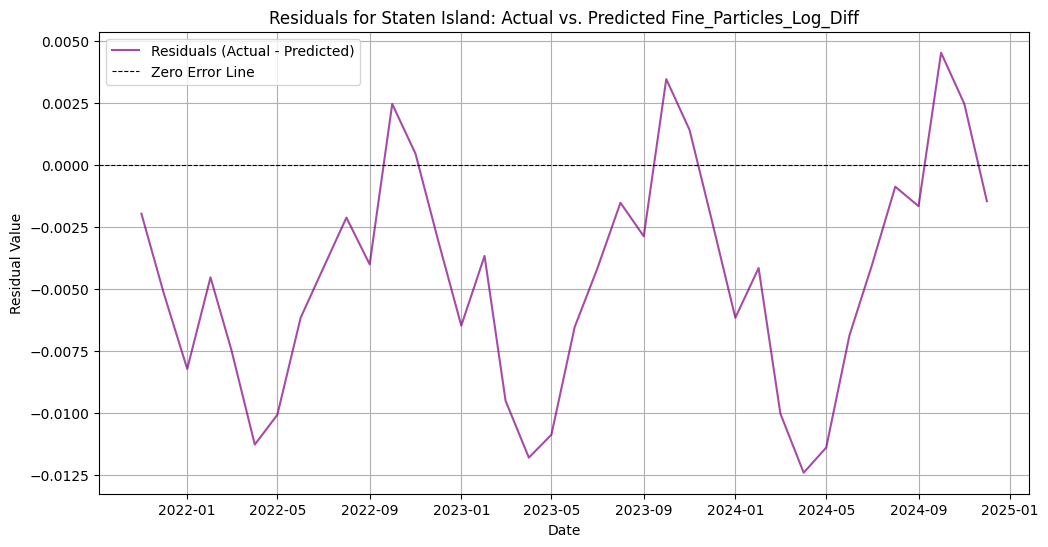


Residuals Summary for Staten Island:
count    38.000000
mean     -0.004522
std       0.004483
min      -0.012402
25%      -0.007317
50%      -0.004153
75%      -0.001727
max       0.004541
dtype: float64
Residuals plotting complete for Staten Island.
All borough residual plots generated!


In [199]:
# Loop through all boroughs and generate residual plots
# for fine particles using the helpder function

# Get a list of all unique borough names from the test dataset
all_borough_names_pt = y_test_pt.index.get_level_values(1).unique().tolist()

# Print a message so it is clear what is happening
print("Generating residual plots for all boroughs Fine Particles...")

# Loop through each borough and generate its residual plot
for borough in all_borough_names_pt:
    # Call the residual plotting function for the current borough
    plot_borough_residuals(borough, y_test_pt, all_borough_predictions_pt)

# Message after al the plots are made
print("All borough residual plots generated!")

Generating residual plots for all boroughs NO2...
Calculating and plotting residuals for Bronx...


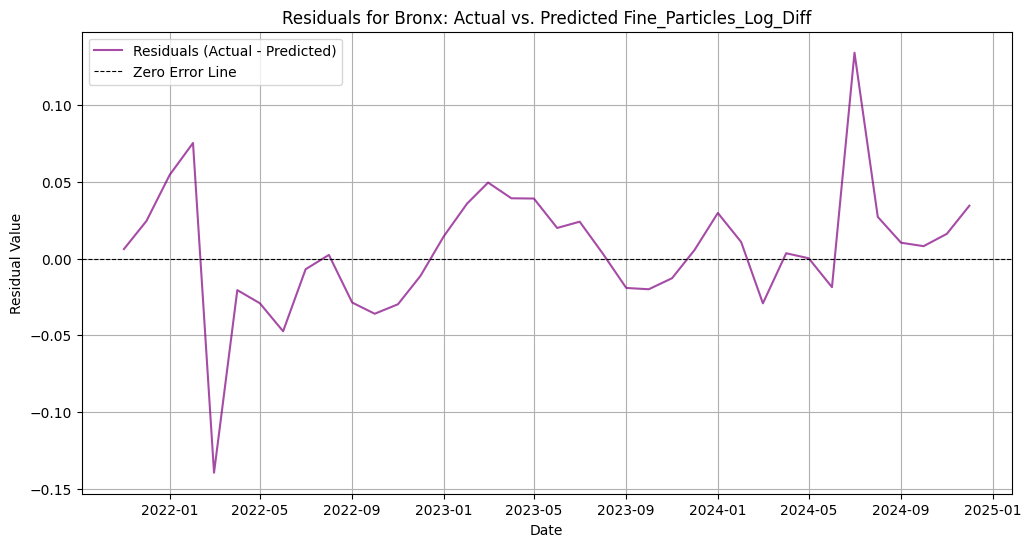


Residuals Summary for Bronx:
count    38.000000
mean      0.005772
std       0.042154
min      -0.139588
25%      -0.019027
50%       0.005902
75%       0.026510
max       0.134167
dtype: float64
Residuals plotting complete for Bronx.
Calculating and plotting residuals for Brooklyn...


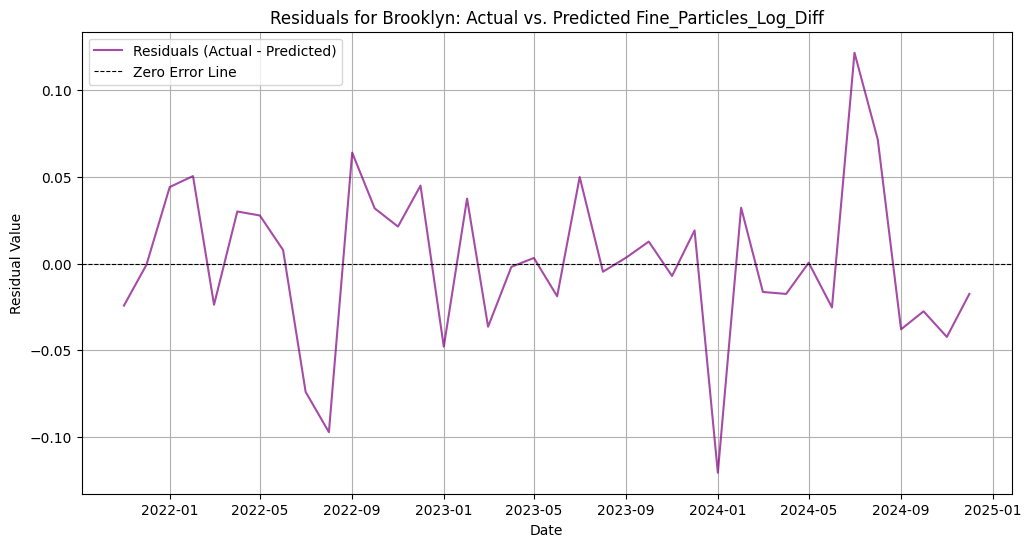


Residuals Summary for Brooklyn:
count    38.000000
mean      0.000804
std       0.046352
min      -0.120764
25%      -0.024175
50%      -0.000155
75%       0.031370
max       0.121662
dtype: float64
Residuals plotting complete for Brooklyn.
Calculating and plotting residuals for Manhattan...


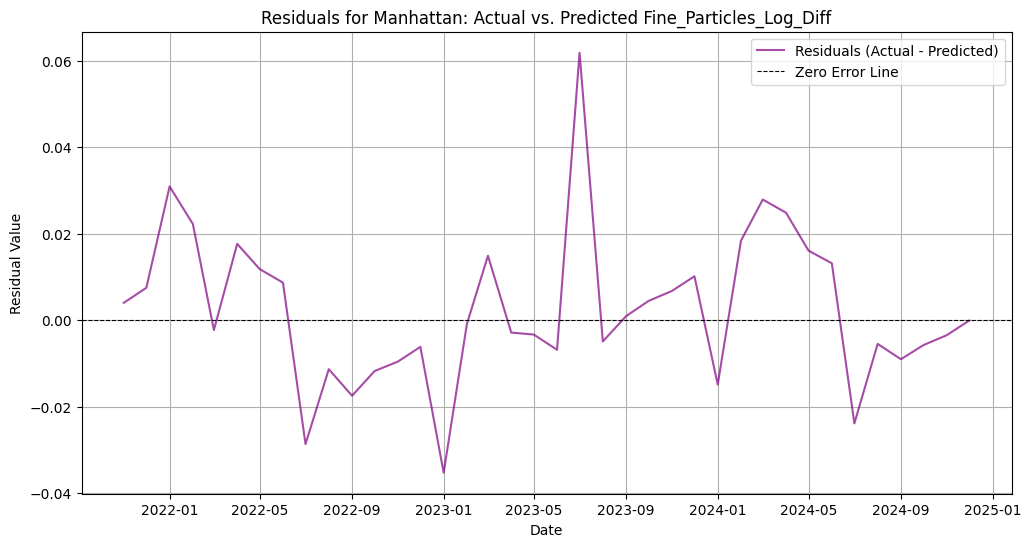


Residuals Summary for Manhattan:
count    38.000000
mean      0.002566
std       0.018012
min      -0.035318
25%      -0.006705
50%      -0.000486
75%       0.012810
max       0.061863
dtype: float64
Residuals plotting complete for Manhattan.
Calculating and plotting residuals for Queens...


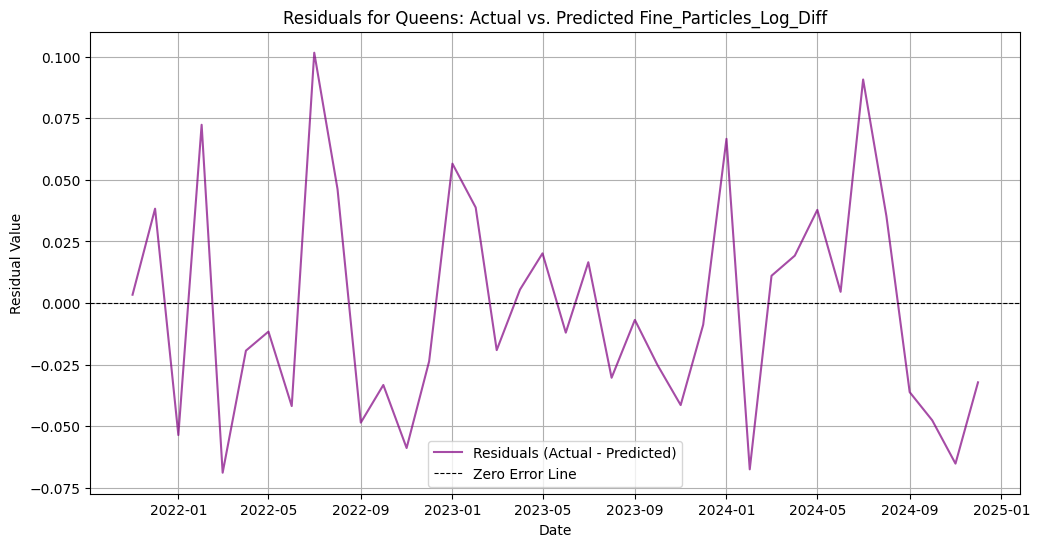


Residuals Summary for Queens:
count    38.000000
mean     -0.002308
std       0.045010
min      -0.068909
25%      -0.035468
50%      -0.010211
75%       0.031506
max       0.101605
dtype: float64
Residuals plotting complete for Queens.
Calculating and plotting residuals for Staten Island...


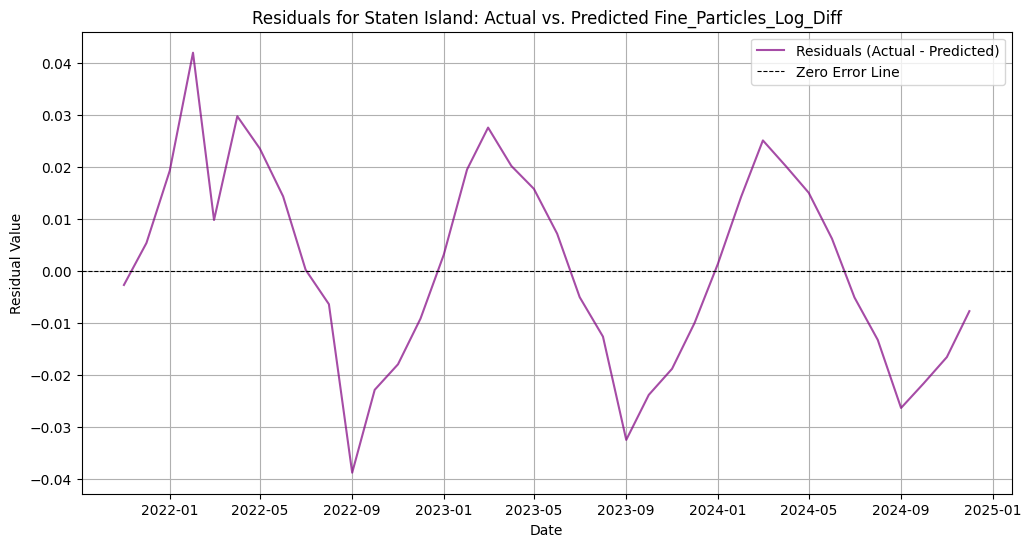


Residuals Summary for Staten Island:
count    38.000000
mean      0.000772
std       0.019209
min      -0.038725
25%      -0.013062
50%       0.000810
75%       0.015614
max       0.041943
dtype: float64
Residuals plotting complete for Staten Island.
All borough residual plots generated!


In [200]:
# Loop through all boroughts and make residual plots
# for NO2 using the resdiaul plotting function

# Get a list of all unique borough names from the NO2 test dataset
all_borough_names_n2t = y_test_n2t.index.get_level_values(1).unique().tolist()

# Print a message to show that the process has started
print("Generating residual plots for all boroughs NO2...")

# Loop through each borough and make the residual plot
for borough in all_borough_names_n2t:
    # Call the residual plotting function for the current borough
    plot_borough_residuals(borough, y_test_n2t, all_borough_predictions_n2t)

print("All borough residual plots generated!")

c:\Users\Xerouz\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 145ms/step


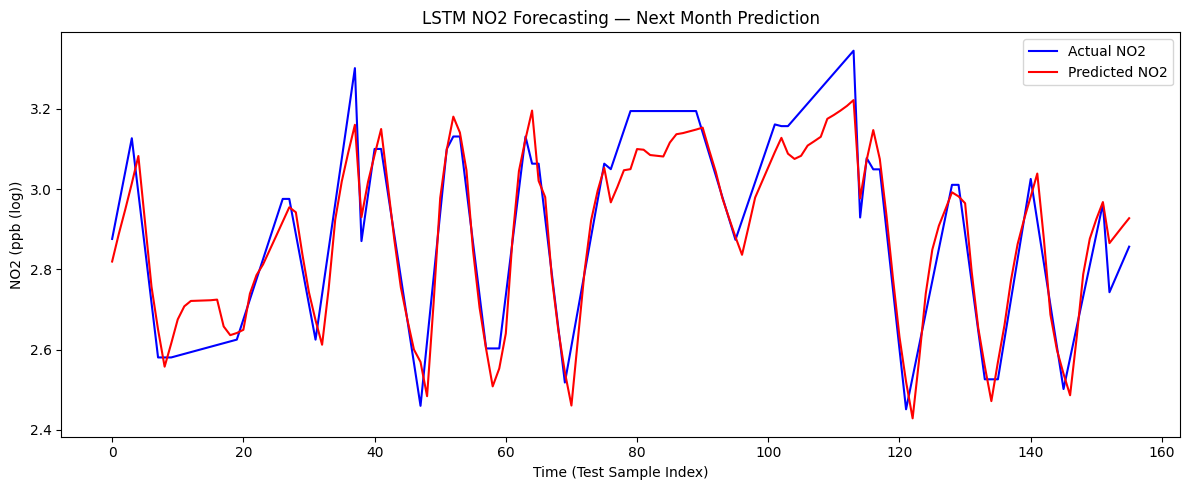

c:\Users\Xerouz\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 146ms/step


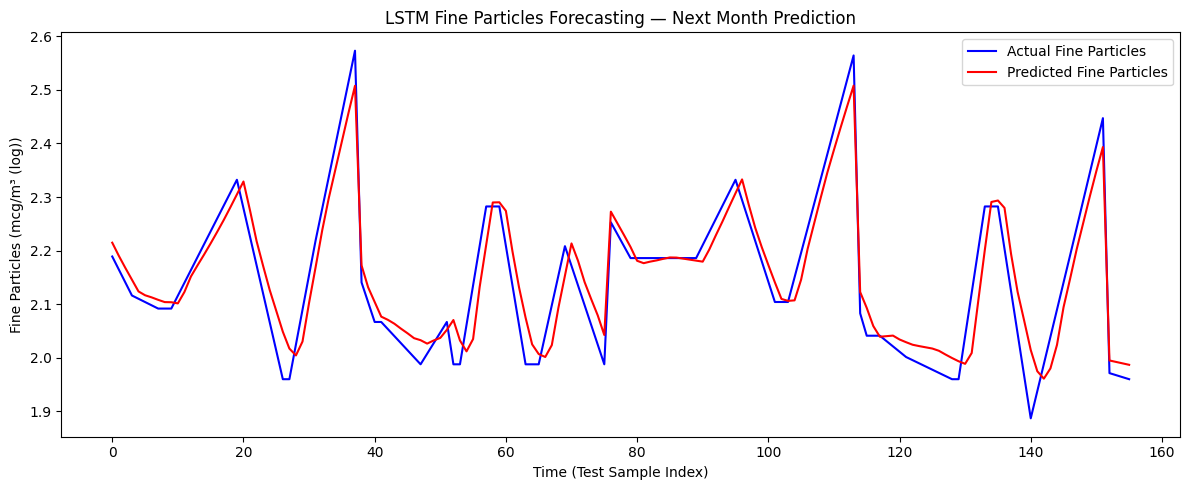

NO2 Model Performance:
R-squared : 0.902
RMSE : 0.064
MAE : 0.051
MAPE : 1.779%

Fine Particles Model Performance:
R-squared : 0.92
RMSE : 0.041
MAE : 0.034
MAPE : 1.625%


In [201]:
# Setting up the LSTM (Long Short-Term Memory) model
# This model is used for time-series prediction of NO2 and fine particle levels
# Also made performance settings, imported needed libraries, and set
# random seeds to make results reproducible

### code produced by cGPT

# Import the OS module to set the envrionment variables for TensorFlow
import os

# Limit the TensorFlow to use a fixed number of threads for better performance
os.environ["TF_NUM_INTEROP_THREADS"] = "1"

# Limit TensorFlow to use a fixed number of threads for consistency/efficiency
os.environ["TF_NUM_INTRAOP_THREADS"] = "1"

# Reduce TensorFlow logging to only show the main important errors and hide any warning or other information messages
os.environ["TF_CPP_MIN_LOG_LEVEL"]   = "3"

# Python seed for reproducible outputs
os.environ["PYTHONHASHSEED"] = "42"

# Import NumPy for numerical operations and handling arrays
import numpy as np

# Import matplotlib for plotting the results and the model performance visuals
import matplotlib.pyplot as plt

# Import MinMaxScalar to normalize the data into a 0-1 rnage for LSTM training
from sklearn.preprocessing import MinMaxScaler

# Import evaluation metrics  to measure the model's performance
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Import TensorFlow as the backend for machine learning operations
import tensorflow as tf
tf.config.experimental.enable_op_determinism()

# Set a random seed for TensorFlow so that results are reproducible
tf.random.set_seed(42)

# Set a random seed for Numpy to make sure there is consistent outputs across the runs
np.random.seed(42)

# Import the Sequential model type for building the LSTM neural network
from tensorflow.keras.models import Sequential

# Import the LSTM layer and Dense layer for building the neural network components
from tensorflow.keras.layers import LSTM, Dense, Dropout

# Import EarlyStopping to prevent overfitting during training
from tensorflow.keras.callbacks import EarlyStopping

# For this part below it is for defining the LSTM model
# Includes the window size which is how many time steps and model looks back at
# and the feature sets used for predicting NO2 and fine particle levels.
# Also there are target variable that the model should aim to predict

# Number of past time steps the LSTM will use for the prediction
window_size = 3

### NO2 model features

# List of all the features used to predict the NO2 levels
no2_features = [
    # Current NO2 level which is log scaled
    'NO2_Log',
    # Traffic volume as a key influencing factor
    'Traffic_Volume_Log',
    # NO2 value from the previous time step
    'NO2_Log_Lag1',
    # NO2 value from the same season last year
    'NO2_Log_Lag12',
    # Traffic lag from the previous time step
    'Traffic_Volume_Log_Lag1',
    # Traffic lag from the same season last year
    'Traffic_Volume_Log_Lag12'
]

# The target variable for the NO2 model
no2_target = 'NO2_Log'

### Fine particles model features

# List of all the input features use dto predict fine particle levels
pm_features = [
    # Current fine particle level which is log scaled
    'Fine_Particles_Log',
    # Traffic volume as a key driver
    'Traffic_Volume_Log',
    # Previous time step value
    'Fine_Particles_Log_Lag1',
    # Same season last year value
    'Fine_Particles_Log_Lag12',
    # Traffic lag which is from the previous time step
    'Traffic_Volume_Log_Lag1',
    # Traffic lag which is the same season last year
    'Traffic_Volume_Log_Lag12'
]

# The target variable for the fine particles model
pm_target = 'Fine_Particles_Log'

# Helper function that prepares the dataset for the LSTM model
# It builds time-based sequences for each borough on its own, scales the data,
# and combine everything into one final training and testing datasets
# This is super important since LSTM models need sequential input data

# Helper function to prepare LSTM-ready data from the dataframe
def prepare_lstm_data(df, feature_cols, target_col, window, test_ratio = 0.2):
    # Combine feature columns with target column to avoid duplicates if the target is already included
    all_cols = feature_cols + ([target_col] if target_col not in feature_cols else [])

    # Get all of the unique boroughs if the column exists, otherwise treat the whole dataset as one group
    boroughs = df['Borough'].unique() if 'Borough' in df.columns else [None]

    # Start by making the lists to store the training and testing data across all the boroughs
    X_train_all, X_test_all = [], []
    y_train_all, y_test_all = [], []

    # Get rid of the rows with missing values in the chosen columns
    df_clean = df[all_cols + (['Borough'] if 'Borough' in df.columns else [])].dropna()

    # Make scalers for features and target to normalize the data between 0-1
    feat_scaler = MinMaxScaler()
    tgt_scaler  = MinMaxScaler()

    # Fit the feature scaler on the feature columns
    feat_scaler.fit(df_clean[feature_cols])

    # Fit the target scaler on the target column
    tgt_scaler.fit(df_clean[[target_col]])

    # Loop through each of the boroughs on its own to not lose any of the time-series structures
    for borough in boroughs:
        # If working with borough specific data
        if borough is not None:
            # Filter the dataset for the current borough and sort by date if it is availble
            grp = df_clean[df_clean['Borough'] == borough].sort_values('Date') \
                      if 'Date' in df_clean.columns \
                      else df_clean[df_clean['Borough'] == borough]
        else:
            # If there is no borough column, just sort the entire dataset if it is possible
            grp = df_clean.sort_values('Date') if 'Date' in df_clean.columns else df_clean

        # Drop any of the remaining missing values in this group
        grp = grp[all_cols].dropna()

        # Skip this group if it is too small to form sequences
        if len(grp) <= window + 2:
            continue

        # Scale the feature values
        feat_scaled = feat_scaler.transform(grp[feature_cols])

        # Scale the target values
        tgt_scaled  = tgt_scaler.transform(grp[[target_col]])

        # Make the lists to store the sequences for this borough
        X_seq, y_seq = [], []

        # Make the sliding window sequences for the LSTM input
        for i in range(len(feat_scaled) - window):
            # Take a window of feature values
            X_seq.append(feat_scaled[i : i + window])
            # Take the target value right after the window
            y_seq.append(tgt_scaled[i + window, 0])

        # Convert the lists into numpy arrays to help make the model more compatible
        X_seq, y_seq = np.array(X_seq), np.array(y_seq)

        # The split index for training vs testing
        split = int(len(X_seq) * (1 - test_ratio))

        # Append the training seqeunces to the main training list
        # Append the testing sequences to the main testing list
        X_train_all.append(X_seq[:split]);  X_test_all.append(X_seq[split:])

        # Append the training target values to the main training list
        # Append the testing target values to the main testing list
        y_train_all.append(y_seq[:split]);  y_test_all.append(y_seq[split:])

    # Combine all the borough training data into one array
    X_train = np.concatenate(X_train_all, axis = 0)
    
    # Combine all the borough testing data into one array
    X_test = np.concatenate(X_test_all,  axis = 0)

    # Combine all the borough training target data into one array
    y_train = np.concatenate(y_train_all, axis = 0)

    # Combine all the borough testing target data into one array
    y_test = np.concatenate(y_test_all,  axis = 0)

    # Return the prepared datasets alogn with the target scaler which is for the inverse scaling later on
    return X_train, X_test, y_train, y_test, tgt_scaler

# This is another helper function to build and train the LSTM model
# This model is designed to learn the time-based patterns in the data and make predictions
# Also included dropout to reduce overfiting and early stopping to stop any not needed training 

# Helper function to build and train the LSTM model
def build_and_train_lstm(X_train, y_train, window, n_features, label):
    # The LSTM model using a sequential architecture
    model = Sequential([
        # First LSTM layer with 32 units, return sequences for the next LSTM layer
        LSTM(32, activation = 'tanh', return_sequences = True,
             input_shape = (window, n_features)),

        # Dropout layer to prevent overfitting by randomly disabling some neurons
        Dropout(0.1),

        # Second LSTM layer with 16 units this time, and it outputs a single sequence with no return sequences
        LSTM(16, activation = 'tanh', return_sequences = False),

        # Another dropout layer for regularization
        Dropout(0.1),

        # Dense layer to make the process learned features
        Dense(16, activation = 'relu'),

        # Final output layer with one neuron for prediction
        Dense(1)
    ])

    # Compile the model using the Adam optimizer (asked cGPT about this) and mean squared error loss
    model.compile(
        # Controls how weights are updated during training
        optimizer = tf.keras.optimizers.Adam(learning_rate = 0.001),
        # Loss function for regression problems
        loss = 'mse',
        # Track the mean absolute error during training
        metrics = ['mae']
    )
    # This is the early stopping to prevent any overfitting and stop training when valdiation stops getting better
    early_stop = EarlyStopping(
        # Monitor the validation loss
        monitor = 'val_loss',
        # Number of epochs to wait before stopping
        patience = 20,
        # Retore the best model weights after stopping is done
        restore_best_weights = True
    )

    # Train the model using the training data
    model.fit(
        # Input features and target values
        X_train, y_train,
        # Use 20% of training data for validation
        validation_split = 0.2,
        # Max nubmer of training iterations made it 300 so that the results can be very accurate
        epochs = 300,
        # Number of samples per batch which is 16 and is for efficient training
        batch_size = 16,
        # Keep the order since this is using time-series data
        shuffle = False,
        # Use the early stopping during training
        callbacks = [early_stop],
        # Hold back the training output so that the output is not all messy
        verbose = 0
    )

    # Finally returned the trained model
    return model

# This is another helper function to evaluate the model's predictions as well as visualize the results
# Calculate several performance metrics and then plot the actual vs predicted values to easily see how well the model did

# Helper function to evaluate the model's predictions and visualize the results
def evaluate_and_plot(y_actual, y_pred, label, unit_label):
    # Calculate the R-squared to se how well the model explains the variance in the data
    r2 = r2_score(y_actual, y_pred)
    # Calculate the RMSE to measure the average size of prediction errors
    rmse = np.sqrt(mean_squared_error(y_actual, y_pred))
    # Calculate the MAE to get the average absolute difference between actual and predicted values
    mae = mean_absolute_error(y_actual, y_pred)
    # Make a mask to avoid division by zero when calculating the MAPE so no errors pop up
    mask = y_actual != 0
    # Calculate the MAPE which is the percentage error using only non zero actual values
    mape = np.mean(np.abs((y_actual[mask] - y_pred[mask]) / y_actual[mask])) * 100

    # Limit the number of points plotted so that the graph does not get too crowded
    cutoff = min(156, len(y_actual))

    # Get the actual values for plotting
    y_plot = y_actual[:cutoff]
    
    # Get the predicted values for plotting
    pred_plot = y_pred[:cutoff]

    # Make the figure
    plt.figure(figsize=(12, 5))

    # Plot the actual values in blue
    plt.plot(y_plot, label=f'Actual {label}', color='blue')

    # Plot the predicted values in red
    plt.plot(pred_plot, label=f'Predicted {label}', color='red')

    # Add a title to describes what the plot represents
    plt.title(f'LSTM {label} Forecasting — Next Month Prediction')

    # Label the y-axis with the varialble name and units
    plt.ylabel(f'{label} ({unit_label})')

    # Label the x-axis as time which is based on the test sample index
    plt.xlabel('Time (Test Sample Index)')

    # Show the legend to see the actual vs predicted lines
    plt.legend()

    # Fix the layout of it so nothing overlaps each other
    plt.tight_layout()

    # Display the plot
    plt.show()

    # Return the calculated metrics rounded to 3 decimal places
    return round(r2, 3), round(rmse, 3), round(mae, 3), round(mape, 3)

# Prepare the dataframes for LSTM modeling
# Reset the index and sort the data by Borough and Date to maintain proper time order
# Also get rid of the missing values so that the model can actually train properly

# Prepare the NO2 dataframe by resetting the index, sorting by Borough and date, and dropping all of the missing values
df_no2_lstm = df_n2t_filled.reset_index().sort_values(['Borough', 'Date']).dropna()

# Prepare the Fine Particles dataframe by resetting the index, sorting by Borough and date, and dropping all of the missing values
df_pt_lstm = df_pt_filled.reset_index().sort_values(['Borough', 'Date']).dropna()

# Build and evaluate the LSTM model for predicting NO2 levels,
# First prepare the data into sequences, train the model, generate the predictions,
# and then convert them back to the original scale, and the see how well the model actuall performed

# Prepare the NO2 data for the LSTM model which makes sequences and splits into training and test sets
X_train_no2, X_test_no2, y_train_no2, y_test_no2, scaler_no2 = prepare_lstm_data(
    df_no2_lstm, no2_features, no2_target, window=window_size
)

# Build and train the LSTM model using the prepared training data
model_no2 = build_and_train_lstm(
    X_train_no2, y_train_no2, window_size, len(no2_features), label = "NO2"
)

# Make predictions on the test set and convert them back to the original scale
pred_no2 = scaler_no2.inverse_transform(model_no2.predict(X_test_no2)).flatten()

# Convert the actual test values back to the original scale to compare them
actual_no2 = scaler_no2.inverse_transform(y_test_no2.reshape(-1, 1)).flatten()

# Analyze the model's performance and make a plot of the actual vs predicted values
r2_no2, rmse_no2, mae_no2, mape_no2 = evaluate_and_plot(
    actual_no2, pred_no2, label = 'NO2', unit_label = 'ppb (log)'
)

# Build and evaluate the LSTM model for predicting fine particle levels,
# Just like the NO2 model, we prepare the data, train the model, make prediction,
# and them convert them back to the original scale, and then see how well the model actually performed

# Prepare the fine particles data for the LSTM model which makes the sequences and splits into training and test sets
X_train_pm, X_test_pm, y_train_pm, y_test_pm, scaler_pm = prepare_lstm_data(
    df_pt_lstm, pm_features, pm_target, window = window_size
)

# Build and train the LSTM model using the prepared training data
model_pm = build_and_train_lstm(
    X_train_pm, y_train_pm, window_size, len(pm_features), label = "Fine Particles"
)

# Make the predictions on the test set and convert them back to the original scale
pred_pm = scaler_pm.inverse_transform(model_pm.predict(X_test_pm)).flatten()

# Convert the actual test values back to the original scale to compare them
actual_pm = scaler_pm.inverse_transform(y_test_pm.reshape(-1, 1)).flatten()

# Analyze the model performance and make a plot of the actual vs predicted values
r2_pm, rmse_pm, mae_pm, mape_pm = evaluate_and_plot(
    actual_pm, pred_pm, label='Fine Particles', unit_label = 'mcg/m³ (log)'
)

# Print out the performance metrics for both LSTM models
# Gives a summary of how well each model perofrmed in terms of accuracy
# and the prediction error, making it easy to compare the NO2 and fine particle results

# NO2 Model Performance
print("NO2 Model Performance:")

# R-squared value for NO2 which is how well the model explains the variance in the data
print(f"R-squared : {r2_no2}")

# RMSE for NO2 which is the overall prediction error magnitude
print(f"RMSE : {rmse_no2}")

# MAE for NO2 which is the average absolute prediction error
print(f"MAE : {mae_no2}")

# MAPE for NO2 which is the percentage based error
print(f"MAPE : {mape_no2}%")

# Seperate the outputs
print()

# Fine Particles Model Performance
print("Fine Particles Model Performance:")

# R-squared value for fine particles which is how well the model explains the variance in the data
print(f"R-squared : {r2_pm}")

# RMSE for fine particles which is the overall prediction error magnitude
print(f"RMSE : {rmse_pm}")

# MAE for fine particles which is the average absolute prediction error
print(f"MAE : {mae_pm}")

# MAPE for fine particles which is the percentage based error
print(f"MAPE : {mape_pm}%")